# Does the Payout–Leverage Relationship Vary with the Interest Rate Regime?
### Industry-Level Evidence from US Non-Financial Firms, 1999–2025 — *analysis pipeline*

Milan Kalajdžić · University of Warsaw, Faculty of Economic Sciences · *Quantitative Finance MA*
Supervisor: dr hab. Piotr Boguszewski

---

Empirical pipeline for Chapters **4 (Data)**, **5 (Methodology)** and **6 (Results)**. It builds an
**industry × year panel** from the Damodaran datasets (1999–2025), merges macro series from **FRED**, and
estimates fixed-effects panel regressions of payout on leverage with a **leverage × rate-regime interaction**
(the central test of **H2**), plus the **H3** tangibility moderation.

> **Full 27-year panel.** Years are auto-detected from each file's internal date stamp (newer files) or its
> filename (older archives). The loader is **era-proof**: it handles Damodaran's three structural layouts
> (the 1999–2012 `Sheet1` files, the 2013–2017 transition, and the 2018+ `Industry Averages` files) and
> selects columns by keyword so year-to-year renames don't break it.

> **Two things the long panel changes vs an 8-year run:**
> 1. **Regime definition.** With 1999–2025 spanning several tightening cycles (early-2000s, mid-2000s,
>    2022+), the **rate-level threshold** is the primary regime variable (not the post-2022 binary, which
>    would lump 23 disparate years together). Both are reported.
> 2. **Industry reconciliation.** Damodaran reorganised his classification at **2012→2013**. A conservative
>    rename map fixes unambiguous variants; a **stable-core sample** (industries present ≥ N years) provides
>    a robustness check immune to the reclassification. See §2 and Appendix B.

> 3. **Data-quality fixes (Sept 2026).** Damodaran's 2013–2015 capex files report depreciation on a
>    different basis (industry depreciation roughly halves while capex does not), which inflates
>    Cap Ex/Depreciation and scrambles the industry ranking. Depreciation-based tangibility is set to missing
>    in those years (per-year check in §2). The H3 model now includes the tangibility main effect, and the
>    H3 proxy-robustness loop applies the same industry reconciliation as the main panel.

| Section | Thesis |
|---|---|
| 0 Setup · 1 Load · 2 Filters & reconciliation | §5.6, §4.1–4.2, App. B |
| 3 FRED & regime · 4 Variables | §4.1, §4.3 |
| 5 Descriptives · 6 Baseline · 7 Interaction (H1/H2) · 8 Tangibility (H3) · 8b Dividend smoothing | §4.4, §5–6 |
| 9 Robustness · 10 Tables & verdicts · 11 Figures · 12 Reproducibility | §5.5, §6, App. A/C/D |

## 0 · Setup & configuration  <span style="color:gray">(§5.6)</span>

In [1]:
# Install once:  pip install -r requirements.txt

import warnings, sys, platform, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 70)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": .3})
try:
    from linearmodels.panel import PanelOLS
    HAVE_LM = True
except Exception:
    HAVE_LM = False; print("linearmodels missing -> %pip install linearmodels")
print("Python", sys.version.split()[0], "| pandas", pd.__version__)

Python 3.11.15 | pandas 3.0.2


In [2]:
# ============================ CONFIGURATION ============================
SEARCH_DIRS = ["data", "."]   # searched recursively for the Damodaran .xls files; absent paths ignored

# Tangibility proxy for H3 (capex file has no PP&E/Total Assets; see §4).
#   "capex_deprec"   -> Cap Ex / Depreciation            (PRIMARY: best separates tangible sectors)
#   "netcapex_sales" -> Net Cap Ex / Sales                (robustness)
#   "invcap_sales"   -> 1 / (Sales / Invested Capital)   (robustness)
TANGIBILITY_PROXY = "capex_deprec"
# Damodaran's 2013-2015 capex files report depreciation on a different basis (industry depreciation drops
# by roughly half vs 2012/2016 while capex does not), inflating Cap Ex/Depreciation and scrambling the
# industry ranking. Proxies built from depreciation are set to missing in these years (see the §2 check).
TANG_BREAK_YEARS = [2013, 2014, 2015]
DEPREC_PROXIES   = {"capex_deprec", "netcapex_sales"}

# Rate regime (§4.3.3). With the long panel the threshold captures multiple cycles.
HIGH_RATE_RULE = "threshold"   # "threshold" (primary) or "post2022"
FFR_THRESHOLD  = 3.0           # annual-avg fed funds % defining "high"
HIKE_THRESHOLD = 0.25          # rise in annual-avg fed funds (pp) that counts as a hiking year (§8b)
RECLASS_YEAR   = 2013          # Damodaran's industry reclassification: year-on-year changes across it are
                               # composition shifts, so change/lag models in §8b drop this year

# Equivalence test for H2 (§9b): largest regime effect still considered economically negligible,
# in payout-ratio units per 1 SD of leverage (0.05 is about 14% of the mean payout of 0.35).
EQUIV_MARGIN = 0.05

# FRED macro data:
#   "snapshot" -> pinned monthly/quarterly vintage in data/fred/fred_snapshot.csv (exactly reproducible)
#   "live"     -> download the current vintage with pandas-datareader (GDP is revised over time)
FRED_SOURCE   = "snapshot"
FRED_SNAPSHOT = Path("data/fred/fred_snapshot.csv")

# Sample construction
WINSOR_P         = 0.01
CROSSFILE_MIN_AGREE = 0.75     # min share of industries whose divfund payout matches divfcfe D/NI (±5%)
EXCLUDE_FIN_UTIL = True
MIN_YEARS_CORE   = 20          # stable-core robustness: keep industries present >= this many years
COVID_YEARS      = [2020, 2021]

OUTDIR = Path("outputs"); OUTDIR.mkdir(exist_ok=True)
print("Config OK | regime:", HIGH_RATE_RULE, "| tangibility:", TANGIBILITY_PROXY,
      "| core>=", MIN_YEARS_CORE, "yrs | FRED:", FRED_SOURCE)

Config OK | regime: threshold | tangibility: capex_deprec | core>= 20 yrs | FRED: snapshot


## 1 · Load the Damodaran datasets  <span style="color:gray">(§4.1–4.2)</span>

`divfund` (payout, ROE, market cap) · `divfcfe` (dividends, FCFE) · `wacc` (leverage D/(D+E), tax) ·
`capex` (tangibility proxy). The readers below are **era-proof**: they locate the industry sheet and header
row wherever they sit, derive the data year from the internal stamp or filename, and match columns by
keyword. *Verified against every file from 1999 to 2025.*

In [3]:
def read_industry_sheet(path, scan=45):
    """Locate and read the industry table across all Damodaran layouts (1999-2025)."""
    xl = pd.ExcelFile(path)
    named = [s for s in xl.sheet_names if "industry" in s.lower()]
    for sh in named + [s for s in xl.sheet_names if s not in named]:
        raw = pd.read_excel(path, sheet_name=sh, header=None, nrows=scan)
        if raw.empty:
            continue
        for i in range(len(raw)):
            if str(raw.iloc[i, 0]).strip().lower().startswith("industry"):
                df = pd.read_excel(path, sheet_name=sh, header=i).dropna(how="all")
                df = df.rename(columns={df.columns[0]: "industry"})
                df["industry"] = df["industry"].astype(str).str.strip()
                return df[df["industry"].str.lower() != "nan"].copy()
    raise ValueError(f"No industry table found in {path}")

def pick(df, *keys):
    keys = [k.lower() for k in keys]
    for c in df.columns:
        if all(k in str(c).lower() for k in keys):
            return c
    return None

def pick_fcfe(df):
    """FCFE level column (not a ratio): starts with 'fcfe', no '/'. Prefers 'before debt'."""
    for c in df.columns:
        cl = str(c).lower().strip()
        if cl.startswith("fcfe") and "/" not in str(c):
            return c
    return None

def pick_div(df):
    """Dividend level column ($), excluding ratios, buybacks, payout, yield."""
    for c in df.columns:
        cl = str(c).lower()
        if "dividend" in cl and "/" not in str(c) and not any(
                e in cl for e in ["yield", "buyback", "net income", "payout"]):
            return c
    return None

def data_year(path):
    """Data year: internal 'Date updated' stamp (year-1) if present, else filename (Y2K pivot)."""
    try:
        xl = pd.ExcelFile(path)
        for sh in xl.sheet_names:
            raw = pd.read_excel(path, sheet_name=sh, header=None, nrows=6)
            for i in range(len(raw)):
                if "date updated" in str(raw.iloc[i, 0]).lower():
                    return pd.to_datetime(raw.iloc[i, 1]).year - 1
    except Exception:
        pass
    m = re.search(r"(\d{2,4})(?=\D*$)", Path(path).stem)
    if m:
        n = int(m.group(1))
        return n if n >= 100 else (1900 + n if n >= 50 else 2000 + n)
    return None

def discover_sources(token):
    found = {}
    for d in SEARCH_DIRS:
        d = Path(d)
        if not d.exists():
            continue
        for f in sorted(d.rglob(f"{token}*.xls*")):
            if f.name.startswith("~$"):
                continue
            y = data_year(f)
            if y is not None:
                found.setdefault(y, f)
    return found

In [4]:
# tangibility proxy from capex (see §4)
def _tangibility(cx):
    if TANGIBILITY_PROXY == "netcapex_sales":
        c = pick(cx, "net cap ex", "sales") or pick(cx, "cap ex", "sales")
    elif TANGIBILITY_PROXY == "invcap_sales":
        c = pick(cx, "sales", "capital") or pick(cx, "sales", "invested")
        if c is None:                          # column absent in older capex files
            return pd.Series(np.nan, index=cx.index)
        return 1.0 / pd.to_numeric(cx[c], errors="coerce").replace(0, np.nan)
    else:
        c = pick(cx, "cap ex", "deprec")       # PRIMARY (present every year)
    if c is None:
        return pd.Series(np.nan, index=cx.index)
    return pd.to_numeric(cx[c], errors="coerce")

def load_year(year):
    dv = read_industry_sheet(SOURCES["divfund"][year])
    wc = read_industry_sheet(SOURCES["wacc"][year])
    out = pd.DataFrame({"industry": dv["industry"], "year": year})
    out["payout"] = pd.to_numeric(dv[pick(dv, "dividend", "payout")], errors="coerce")
    out["roe"]    = pd.to_numeric(dv[pick(dv, "roe")], errors="coerce")
    mc = pick(dv, "market cap")
    out["mktcap"] = pd.to_numeric(dv[mc], errors="coerce") if mc else np.nan
    out = out.merge(pd.DataFrame({
        "industry": wc["industry"],
        "lev": pd.to_numeric(wc[pick(wc, "d/(d+e)")], errors="coerce"),
        "tax": pd.to_numeric(wc[pick(wc, "tax")], errors="coerce"),
    }), on="industry", how="left")
    if year in SOURCES["divfcfe"]:
        fc = read_industry_sheet(SOURCES["divfcfe"][year])
        dcol, fcol = pick_div(fc), pick_fcfe(fc)
        tot, ni = pick(fc, "dividends", "buyback"), pick(fc, "net income")
        f = pd.DataFrame({"industry": fc["industry"]})
        if dcol:
            f["div_usd"] = pd.to_numeric(fc[dcol], errors="coerce")   # $m, used for checks and §8b
        if ni:
            f["ni_usd"] = pd.to_numeric(fc[ni], errors="coerce")
        if dcol and fcol:
            f["div_to_fcfe"] = (pd.to_numeric(fc[dcol], errors="coerce")
                                / pd.to_numeric(fc[fcol], errors="coerce").replace(0, np.nan))
        if tot and ni:
            f["totpayout_ni"] = (pd.to_numeric(fc[tot], errors="coerce")
                                 / pd.to_numeric(fc[ni], errors="coerce").replace(0, np.nan))
        out = out.merge(f, on="industry", how="left")
    if year in SOURCES["capex"]:
        cx = read_industry_sheet(SOURCES["capex"][year])
        out = out.merge(pd.DataFrame({"industry": cx["industry"], "tangibility": _tangibility(cx)}),
                        on="industry", how="left")
    return out

SOURCES = {t: discover_sources(t) for t in ["divfund", "divfcfe", "wacc", "capex"]}
all_years = sorted(set().union(*[set(v) for v in SOURCES.values()]))
grid = pd.DataFrame({t: ["Y" if y in SOURCES[t] else "." for y in all_years] for t in SOURCES},
                    index=all_years)
grid.index.name = "year"
print(f"Coverage ({len(all_years)} years {min(all_years)}-{max(all_years)}):")
print(grid.T.to_string())

years = sorted(set(SOURCES["divfund"]) & set(SOURCES["wacc"]))
raw = pd.concat([load_year(y) for y in years], ignore_index=True)
print(f"\nRaw panel: {len(years)} years | {raw['industry'].nunique()} distinct names | {len(raw)} rows")
raw.head()

Coverage (27 years 1999-2025):
year    1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
divfund    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
divfcfe    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
wacc       Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y
capex      Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y    Y



Raw panel: 27 years | 219 distinct names | 2652 rows


,industry,year,payout,roe,mktcap,lev,tax,div_usd,ni_usd,div_to_fcfe,tangibility,totpayout_ni
0,Advertising,1999,0.246424,0.134948,58326.4895,0.098560,0.447821,266.0,1079.0,0.214171,0.852036,NaN
1,Aerospace/Defense,1999,0.245589,0.133937,111866.7804,0.267524,0.348131,1455.0,5926.0,0.254460,0.902343,NaN
2,Air Transport,1999,0.052681,0.189568,84075.3787,0.346738,0.372312,385.0,7314.0,0.434537,2.203980,NaN
3,Alternate Energy,1999,0.118465,0.139224,13400.0999,NaN,NaN,55.0,461.0,0.364238,1.849453,NaN
4,Aluminum,1999,0.166057,0.092600,35307.2390,0.483904,0.288303,259.0,1562.0,0.447323,1.279888,NaN


## 2 · Sample construction, filters & industry reconciliation  <span style="color:gray">(§4.2, App. B)</span>

- Drop aggregate rows; exclude **financials & regulated utilities** (era-aware keyword list).
- **Reconcile industry names** across the 2012→2013 reclassification via a *conservative* map — only
  unambiguous spelling/punctuation variants and clear 1:1 relabels (extend `INDUSTRY_RENAME` as needed).
- Set depreciation-based tangibility to missing in the 2013–2015 break years (see the data check below).
- Winsorise ratio variables; report industry **persistence** (Appendix B) and define the **stable core**.

In [5]:
AGG_ROWS = ["Total Market", "Total Market (without financials)", "Grand Total",
            "Market", "Other", "Unclassified"]
# era-aware financial / regulated-utility exclusions (lower-cased substring match)
FIN_UTIL_KEYS = ["bank", "insurance", "financ", "investment", "utilit", "power", "r.e.i.t", "reit",
                 "reinsurance", "brokerage", "trust", "thrift", "securities", "electric util",
                 "natural gas (distrib", "natural gas util", "water utility", "telecom. utility",
                 "public/private equity", "real estate"]

# Conservative reconciliation: unambiguous variants + clear 1:1 relabels only.
INDUSTRY_RENAME = {
    # --- spelling / punctuation / typo variants ---
    "Furn./Home Furnishings": "Furn/Home Furnishings",
    "Paper & Forest Products": "Paper/Forest Products",
    "Office Equip & Supplies": "Office Equip/Supplies",
    "Oilfield Services/Equip.": "Oilfield Svcs/Equip.",
    "Semiconductor Cap Eq": "Semiconductor Equip",
    "Semiconductor Cap Equip": "Semiconductor Equip",
    "Manuf. Housing/Rec Veh": "Manuf. Housing/RV",
    "Computer Software & Svcs": "Computer Software/Svcs",
    "Heavy Truck/Equip Makers": "Heavy Truck & Equip",
    "Natural Gas (Diversified": "Natural Gas (Div.)",
    "Natural Gas (Diversified)": "Natural Gas (Div.)",
    "Publshing & Newspapers": "Publishing & Newspapers",
    "Retail Automotive": "Retail (Automotive)",
    "Retail Building Supply": "Retail (Building Supply)",
    "Auto Parts (OEM)": "Auto Parts",
    "Auto Parts (Replacement)": "Auto Parts",
    "Trucking/Transp. Leasing": "Trucking",
    "Gold/Silver Mining": "Precious Metals",
    # --- clear 1:1 relabels across the 2013 reclassification ---
    "Beverage (Soft Drink)": "Beverage (Soft)",
    "Educational Services": "Education",
    "Railroad": "Transportation (Railroads)",
    "Restaurant": "Restaurant/Dining",
    "Tire & Rubber": "Rubber& Tires",
    "Metals & Mining (Div.)": "Metals & Mining",
    "Environmental": "Environmental & Waste Services",
    "Newspaper": "Publishing & Newspapers",
    "Publishing": "Publishing & Newspapers",
}

def is_fin_util(name):
    nl = str(name).lower()
    return any(k in nl for k in FIN_UTIL_KEYS)

def clean_sample(df):
    df = df.copy()
    df["industry"] = df["industry"].replace(INDUSTRY_RENAME)
    df = df[~df["industry"].isin(AGG_ROWS)]
    if EXCLUDE_FIN_UTIL:
        m = df["industry"].apply(is_fin_util)
        print(f"Excluding {int(m.sum())} financial/utility rows across all years")
        df = df[~m]
    # collapse any duplicate industry-year created by the rename map (mean of numeric cols)
    num = [c for c in df.select_dtypes("number").columns if c != "year"]
    df = df.groupby(["industry", "year"], as_index=False)[list(num)].mean()
    return df.reset_index(drop=True)

def winsorize(df, cols, p=WINSOR_P):
    df = df.copy()
    for c in cols:
        if c in df:
            lo, hi = df[c].quantile([p, 1 - p]); df[c] = df[c].clip(lo, hi)
    return df

panel = clean_sample(raw)
panel_prewin = panel.copy()      # kept for the per-year data-quality check below

# Cross-file consistency: divfund's payout ratio vs dividends / net income from divfcfe (same year, same
# industry). A year in which most industries disagree points to a scrambled divfcfe file (e.g. 2007, where
# the net-income column does not match the industries); measures built from divfcfe are set to missing there.
_r = raw[raw["industry"].replace(INDUSTRY_RENAME).isin(panel["industry"])]
_calc = _r["div_usd"] / _r["ni_usd"].where(_r["ni_usd"] > 0)
_both = _r["payout"].gt(0) & _calc.notna()
_agree = ((_r["payout"] - _calc).abs() / _calc).lt(0.05)
crossfile_agreement = _agree[_both].groupby(_r.loc[_both, "year"]).mean().rename("share_agree")
DIVFCFE_BAD_YEARS = sorted(int(y) for y in crossfile_agreement[crossfile_agreement < CROSSFILE_MIN_AGREE].index)
print(f"divfcfe vs divfund agreement below {CROSSFILE_MIN_AGREE:.0%} in {DIVFCFE_BAD_YEARS}: "
      f"divfcfe-based measures set to missing in those years")
panel.loc[panel["year"].isin(DIVFCFE_BAD_YEARS), ["div_to_fcfe", "totpayout_ni"]] = np.nan
panel = panel.drop(columns=["div_usd", "ni_usd"])   # dollar levels stay in `raw` (summed where needed, §8b)

if TANGIBILITY_PROXY in DEPREC_PROXIES:
    brk = panel["year"].isin(TANG_BREAK_YEARS)
    print(f"Tangibility set to missing in {TANG_BREAK_YEARS} (depreciation break): "
          f"{int(panel.loc[brk, 'tangibility'].notna().sum())} obs")
    panel.loc[brk, "tangibility"] = np.nan

panel = winsorize(panel, [c for c in
        ["payout", "div_to_fcfe", "totpayout_ni", "lev", "roe", "tax", "tangibility"] if c in panel])

# persistence / stable core (Appendix B)
persist = panel.groupby("industry")["year"].nunique().sort_values(ascending=False)
CORE = persist[persist >= MIN_YEARS_CORE].index.tolist()
panel["in_core"] = panel["industry"].isin(CORE)
print(f"\nAnalysis sample: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"= {len(panel)} obs")
print(f"Stable core (>= {MIN_YEARS_CORE} yrs): {len(CORE)} industries, {int(panel['in_core'].sum())} obs")
panel.describe().T.round(3)

Excluding 480 financial/utility rows across all years
divfcfe vs divfund agreement below 75% in [2000, 2007]: divfcfe-based measures set to missing in those years
Tangibility set to missing in [2013, 2014, 2015] (depreciation break): 226 obs

Analysis sample: 143 industries x 27 years = 2116 obs
Stable core (>= 20 yrs): 46 industries, 1204 obs


,count,mean,std,min,25%,50%,75%,max
year,2116.0,2011.961,7.763,1999.000,2005.000,2012.000,2019.000,2025.000
payout,2030.0,0.349,0.363,0.000,0.138,0.266,0.440,2.386
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
mktcap,2116.0,311546.631,546376.613,1739.300,55796.459,145608.463,362919.876,7857941.525
lev,2115.0,0.238,0.138,0.023,0.135,0.211,0.322,0.638
tax,2115.0,0.156,0.096,0.005,0.081,0.140,0.219,0.421
div_to_fcfe,1961.0,0.371,1.697,-7.682,0.085,0.276,0.543,10.625
tangibility,1882.0,1.281,0.659,0.350,0.856,1.124,1.551,4.221
totpayout_ni,1011.0,0.780,2.222,-14.615,0.504,0.840,1.202,7.997



### Data-quality check: per-year medians  <span style="color:gray">(App. B)</span>

Industry and year fixed effects absorb *level* shifts that hit every industry equally, but a change in how a
variable is **defined** in some years also changes the cross-industry ordering and contaminates the estimates.
The per-year medians below (before winsorising and before the break-year fix) make such breaks visible:

- **Tangibility (Cap Ex/Depreciation)** jumps from ~1.0–1.4 to ~3.8–4.7 in **2013–2015**. The capex files for
  those years report much lower depreciation (Total Market: 908bn in 2012 → 368bn in 2013 → 719bn in 2016), so
  the ratio is inflated and the industry ranking is scrambled. These years are excluded for depreciation-based proxies.
- **Tax rate** falls in steps (2013 reclassification, 2018 TCJA). This is a level shift common to all
  industries, absorbed by the year fixed effects.
- **Dividends/FCFE** is unstable because FCFE is often near zero or negative; it is used only as a robustness DV.
- **Cross-file check.** The payout ratio in `divfund` should equal dividends ÷ net income in `divfcfe`. It does
  (within 5%) for 91–100% of industries in every year **except 2000 and 2007**. In `divfcfe07` the net-income column
  does not belong to the listed industries (e.g. homebuilders report a $9.8bn profit in the year the housing crash
  began). Measures built from `divfcfe` (Dividends/FCFE, total payout) are therefore excluded in those years; the
  main payout variable comes from `divfund` and is unaffected.


Share of industries where divfund payout = divfcfe D/NI (±5%):
year         1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
share_agree  0.99  0.17   1.0   1.0   1.0   1.0   1.0   1.0  0.01   1.0   1.0  0.93  0.99  0.96   1.0  0.99   1.0  0.99   1.0   1.0   1.0  0.96   1.0  0.99   1.0   1.0  0.99 



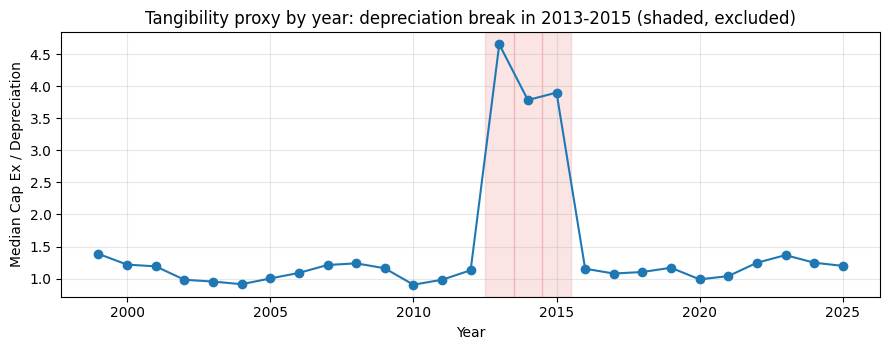

,payout,lev,roe,tax,tangibility,div_to_fcfe
year,,,,,,
1999,0.247,0.175,0.134,0.372,1.385,0.365
2000,0.182,0.206,0.143,0.259,1.218,0.402
2001,0.122,0.213,0.123,0.244,1.191,0.130
2002,0.159,0.241,0.085,0.209,0.982,0.142
2003,0.291,0.195,0.106,0.225,0.954,0.232
2004,0.170,0.156,0.104,0.203,0.913,0.132
2005,0.261,0.161,0.135,0.192,1.002,0.263
2006,0.247,0.153,0.151,0.189,1.089,0.276
2007,0.234,0.149,0.156,0.186,1.212,0.137


In [6]:

chk_cols = ["payout", "lev", "roe", "tax", "tangibility", "div_to_fcfe"]
yearly_medians = panel_prewin.groupby("year")[[c for c in chk_cols if c in panel_prewin]].median().round(3)
yearly_medians.to_csv(OUTDIR / "tab_data_check_yearly_medians.csv")
crossfile_agreement.round(3).to_csv(OUTDIR / "tab_data_check_crossfile.csv")
print("Share of industries where divfund payout = divfcfe D/NI (±5%):")
print(crossfile_agreement.round(2).to_frame().T.to_string(), "\n")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(yearly_medians.index, yearly_medians["tangibility"], "o-", color="tab:blue")
for y in TANG_BREAK_YEARS:
    ax.axvspan(y - .5, y + .5, color="tab:red", alpha=.12)
ax.set_ylabel("Median Cap Ex / Depreciation"); ax.set_xlabel("Year")
ax.set_title("Tangibility proxy by year: depreciation break in 2013-2015 (shaded, excluded)")
fig.tight_layout(); fig.savefig(OUTDIR / "fig_data_check_tangibility.png", dpi=150); plt.show()
yearly_medians


## 3 · FRED macro data & the interest-rate regime  <span style="color:gray">(§4.1, §4.3.3)</span>

In [7]:
FRED_SERIES = ["FEDFUNDS", "GS10", "BAA", "AAA", "GDPC1"]   # monthly, except GDPC1 (quarterly)

def load_fred_snapshot(path=FRED_SNAPSHOT):
    s = pd.read_csv(path, parse_dates=["date"])
    return s.pivot(index="date", columns="series_id", values="value")

def fetch_fred_live(start="1998-01-01"):
    from pandas_datareader import data as pdr
    return pdr.DataReader(FRED_SERIES, "fred", start, pd.Timestamp.today())

def annualise(wide):
    a = wide.resample("YE").mean(); a.index = a.index.year
    out = pd.DataFrame(index=a.index)
    out["ffr"] = a["FEDFUNDS"]                       # annual-average effective fed funds rate
    out["t10"] = a["GS10"]                           # annual-average 10y Treasury yield (monthly GS10)
    out["cred_spread"] = a["BAA"] - a["AAA"]         # Moody's BAA - AAA
    out["gdp_growth"] = a["GDPC1"].pct_change() * 100
    out["ffr_change"] = out["ffr"].diff(); out.index.name = "year"
    return out.reset_index()

if FRED_SOURCE == "live":
    try:
        wide = fetch_fred_live(); print("FRED: live download OK")
    except Exception as e:
        print("FRED live download failed:", e, "-> using the pinned snapshot")
        wide = load_fred_snapshot()
else:
    wide = load_fred_snapshot()
    print(f"FRED: pinned snapshot {FRED_SNAPSHOT} (set FRED_SOURCE='live' to refresh)")
macro = annualise(wide)

def add_regime(m):
    m = m.copy()
    m["high_rate"] = ((m["year"] >= 2022).astype(int) if HIGH_RATE_RULE == "post2022"
                      else (m["ffr"] >= FFR_THRESHOLD).astype(int))
    m["high_rate_post2022"] = (m["year"] >= 2022).astype(int)   # kept for robustness
    return m

macro = add_regime(macro)
# Restrict macro to the Damodaran data range (ffr_change is computed on the full series first, so 1999's
# year-on-year change is preserved). This drops any partial current year and the 1998 lead row.
macro = macro[(macro["year"] >= min(years)) & (macro["year"] <= max(years))].reset_index(drop=True)
panel = panel.merge(macro, on="year", how="left")
print("Regime:", HIGH_RATE_RULE, "| high-rate years:",
      sorted(macro.loc[macro.high_rate == 1, "year"].tolist()))
macro.tail(6)

FRED: pinned snapshot data/fred/fred_snapshot.csv (set FRED_SOURCE='live' to refresh)
Regime: threshold | high-rate years: [1999, 2000, 2001, 2005, 2006, 2007, 2023, 2024, 2025]


,year,ffr,t10,cred_spread,gdp_growth,ffr_change,high_rate,high_rate_post2022
21,2020,0.375833,0.894167,1.125833,-2.081378,-1.782500,0,0
22,2021,0.080000,1.442500,0.688333,6.152022,-0.295833,0,0
23,2022,1.683333,2.951667,0.997500,2.524215,1.603333,0,1
24,2023,5.024167,3.957500,1.050833,2.934361,3.340833,1,1
25,2024,5.143333,4.208333,0.709167,2.793187,0.119167,1,1
26,2025,4.212500,4.291667,0.645833,2.106338,-0.930833,1,1


## 4 · Variable definitions  <span style="color:gray">(§4.3)</span>

`payout` (Dividend Payout) · `div_to_fcfe` (Dividends/FCFE) · `lev` (D/(D+E)) · `tangibility`
(**Cap Ex/Depreciation proxy** — capex file has no PP&E/Total Assets; correctly ranks capital-heavy
sectors high and intangible sectors low, same ordering as Rajan-Zingales; note the cloud-capex caveat in
§7.4; depreciation-based values missing in 2013–2015) · industry controls `roe`, `tax`, `size`=log(Market Cap) ·
macro controls `gdp_growth`, `cred_spread` · regime `high_rate`, `ffr`, `ffr_change`.

**Note on macro variables.** Anything that varies only over time (the regime dummy, the fed funds rate, GDP growth,
the credit spread) is perfectly collinear with the year fixed effects. In the two-way FE models these enter only
through interactions with industry variables; `fit_panel` prints any regressor the fixed effects absorb. §9 adds an
industry-FE-only specification in which the macro controls and the regime level are estimated directly.

In [8]:
panel["size"] = np.log(panel["mktcap"].where(panel["mktcap"] > 0))
ANALYSIS_VARS = ["payout", "lev", "roe", "tax", "size", "tangibility",
                 "gdp_growth", "cred_spread", "high_rate", "ffr", "ffr_change"]
print("Non-null counts:")
print(panel[[c for c in ANALYSIS_VARS if c in panel]].notna().sum().to_string())

Non-null counts:
payout         2030
lev            2115
roe            2102
tax            2115
size           2116
tangibility    1882
gdp_growth     2116
cred_spread    2116
high_rate      2116
ffr            2116
ffr_change     2116


## 5 · Descriptive statistics  <span style="color:gray">(§4.4, §6.1)</span>

In [9]:
desc = panel[[c for c in ANALYSIS_VARS if c in panel]].describe().T
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)
desc.to_csv(OUTDIR / "tab_descriptives.csv")

# Overall / between / within standard deviation (Stata xtsum logic). The fixed-effects estimates are
# identified only from the WITHIN variation, which is much smaller than the raw ranges suggest.
def xtsum(df, cols, entity="industry"):
    rows = {}
    for c in cols:
        s = df[[entity, c]].dropna()
        if s.empty:
            continue
        m = s.groupby(entity)[c].transform("mean")
        rows[c] = {"sd_overall": s[c].std(), "sd_between": s.groupby(entity)[c].mean().std(),
                   "sd_within": (s[c] - m + s[c].mean()).std()}
    return pd.DataFrame(rows).T.round(3)

sd_decomp = xtsum(panel, ["payout", "lev", "roe", "tax", "size", "tangibility", "div_to_fcfe"])
sd_decomp.to_csv(OUTDIR / "tab_sd_decomposition.csv")
print("Overall / between / within SD:"); print(sd_decomp.to_string()); print()
desc

Overall / between / within SD:
             sd_overall  sd_between  sd_within
payout            0.363       0.210      0.304
lev               0.138       0.130      0.076
roe               0.128       0.078      0.106
tax               0.096       0.080      0.071
size              1.337       1.349      0.587
tangibility       0.659       0.531      0.442
div_to_fcfe       1.697       0.837      1.625



,count,mean,std,min,25%,50%,75%,max
payout,2030.0,0.349,0.363,0.000,0.138,0.266,0.440,2.386
lev,2115.0,0.238,0.138,0.023,0.135,0.211,0.322,0.638
roe,2102.0,0.133,0.128,-0.364,0.077,0.135,0.192,0.508
tax,2115.0,0.156,0.096,0.005,0.081,0.140,0.219,0.421
size,2116.0,11.833,1.337,7.461,10.929,11.889,12.802,15.877
tangibility,1882.0,1.281,0.659,0.350,0.856,1.124,1.551,4.221
gdp_growth,2116.0,2.304,1.730,-2.576,1.819,2.524,2.946,6.152
cred_spread,2116.0,0.999,0.310,0.646,0.765,0.927,1.099,1.982
high_rate,2116.0,0.331,0.471,0.000,0.000,0.000,1.000,1.000
ffr,2116.0,2.104,2.001,0.080,0.160,1.667,4.212,6.236


In [10]:
corr_vars = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                         "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
panel[corr_vars].corr().round(2)

,payout,lev,roe,tax,size,tangibility,gdp_growth,cred_spread,ffr
payout,1.00,0.12,-0.09,-0.16,0.06,-0.02,0.03,-0.05,-0.05
lev,0.12,1.00,-0.17,-0.01,-0.37,0.11,-0.08,0.08,-0.09
roe,-0.09,-0.17,1.00,0.14,0.24,0.14,0.09,-0.05,0.02
tax,-0.16,-0.01,0.14,1.00,-0.17,0.11,0.09,0.10,0.23
size,0.06,-0.37,0.24,-0.17,1.00,-0.01,0.02,-0.11,-0.01
tangibility,-0.02,0.11,0.14,0.11,-0.01,1.00,-0.01,0.03,0.12
gdp_growth,0.03,-0.08,0.09,0.09,0.02,-0.01,1.00,-0.68,0.26
cred_spread,-0.05,0.08,-0.05,0.10,-0.11,0.03,-0.68,1.00,-0.32
ffr,-0.05,-0.09,0.02,0.23,-0.01,0.12,0.26,-0.32,1.00


## 6 · Baseline panel regression  <span style="color:gray">(§5.2, §6.2)</span>

$$\text{payout}_{it}=\beta\,\text{lev}_{it}+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

Industry & year fixed effects, SE clustered by industry. Substitution view → **β < 0**. $X$ = industry-level controls (ROE, tax rate, size); year-only macro variables are absorbed by $\delta_t$.

In [11]:
def fit_panel(df, depvar, regressors, entity=True, time=True, cluster_time=False, title=""):
    d = df.dropna(subset=[depvar] + regressors).copy()
    ny = d["year"].nunique()
    print(f"=== {title} ===\nobs={len(d)}  industries={d['industry'].nunique()}  years={ny}")
    if ny < 3 or not HAVE_LM:
        if not HAVE_LM:
            print("linearmodels unavailable."); return None
        import statsmodels.formula.api as smf
        print("Short panel -> pooled OLS.\n")
        res = smf.ols(f"{depvar} ~ " + " + ".join(regressors), data=d).fit(cov_type="HC1")
        print(res.summary().tables[1]); return res
    import statsmodels.api as sm
    dd = d.set_index(["industry", "year"]); X = sm.add_constant(dd[regressors])
    res = PanelOLS(dd[depvar], X, entity_effects=entity, time_effects=time,
                   drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True,
                                           cluster_time=cluster_time)
    print(res.summary.tables[1]); print(f"R2(within): {res.rsquared_within:.3f}")
    absorbed = [r for r in regressors if r not in res.params.index]
    if absorbed:
        print("Absorbed by the fixed effects (not estimable, dropped):", absorbed)
    return res

# Industry-level controls. Year-only macro controls would be absorbed by the year fixed effects, so they
# are used only in the industry-FE-only robustness specification (§9).
BASE_CONTROLS  = ["roe", "tax", "size"]
MACRO_CONTROLS = [c for c in ["gdp_growth", "cred_spread"] if panel[c].notna().any()]
res_base = fit_panel(panel, "payout", ["lev"] + BASE_CONTROLS,
                     title="Baseline: payout ~ leverage + controls (two-way FE)")

=== Baseline: payout ~ leverage + controls (two-way FE) ===
obs=2015  industries=142  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4253     0.2376     1.7895     0.0737     -0.0408      0.8913
lev            0.1198     0.1236     0.9694     0.3325     -0.1226      0.3622
roe           -0.5325     0.1278    -4.1670     0.0000     -0.7831     -0.2819
tax           -0.2834     0.1865    -1.5194     0.1288     -0.6491      0.0824
size           0.0012     0.0208     0.0566     0.9548     -0.0396      0.0419
R2(within): 0.046


## 7 · Interaction with the rate regime — H1 & H2  <span style="color:gray">(§5.3, §6.3)</span>

$$\text{payout}_{it}=\beta_1\text{lev}_{it}+\beta_2(\text{lev}_{it}\times\text{HighRate}_t)+\gamma' X_{it}+\alpha_i+\delta_t+\varepsilon_{it}$$

ME of leverage: low-rate $=\beta_1$, high-rate $=\beta_1+\beta_2$. **H2 ⇔ $\beta_2<0$.**

In [12]:
def lincom(res, weights):
    p = res.params
    cov = pd.DataFrame(np.asarray(res.cov if hasattr(res, "cov") else res.cov_params()),
                       index=p.index, columns=p.index)
    w = pd.Series(0.0, index=p.index)
    for k, v in weights.items():
        if k in w: w[k] = v
    est = float(w @ p); se = float(np.sqrt(w.values @ cov.values @ w.values))
    return est, se, (est / se if se else np.nan)

panel["lev_x_high"] = panel["lev"] * panel["high_rate"]
res_int = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                    title="H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE)")
if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
    lo = lincom(res_int, {"lev": 1}); hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
    print("\nMarginal effect of leverage on payout:")
    print(f"  low-rate  (b1)    = {lo[0]:+.4f} (SE {lo[1]:.4f}, t {lo[2]:+.2f})")
    print(f"  high-rate (b1+b2) = {hi[0]:+.4f} (SE {hi[1]:.4f}, t {hi[2]:+.2f})")
    print(f"  interaction b2    = {res_int.params['lev_x_high']:+.4f}  <-- H2 (expect < 0)")

=== H1/H2: payout ~ lev + lev x HighRate + controls (two-way FE) ===
obs=2015  industries=142  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4262     0.2362     1.8041     0.0714     -0.0371      0.8895
lev            0.1240     0.1397     0.8882     0.3746     -0.1499      0.3979
lev_x_high    -0.0112     0.1381    -0.0813     0.9352     -0.2821      0.2597
roe           -0.5322     0.1278    -4.1651     0.0000     -0.7827     -0.2816
tax           -0.2841     0.1883    -1.5090     0.1315     -0.6533      0.0852
size           0.0011     0.0206     0.0527     0.9579     -0.0394      0.0416
R2(within): 0.046

Marginal effect of leverage on payout:
  low-rate  (b1)    = +0.1240 (SE 0.1397, t +0.89)
  high-rate (b1+b2) = +0.1128 (SE 0.1422, t +0.79)
  interaction b2    = -0.

=== Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE) ===
obs=2015  industries=142  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4190     0.2361     1.7746     0.0761     -0.0441      0.8820
lev            0.0823     0.1473     0.5589     0.5763     -0.2066      0.3713
lev_x_ffr      0.0154     0.0291     0.5296     0.5964     -0.0417      0.0726
roe           -0.5359     0.1279    -4.1890     0.0000     -0.7868     -0.2850
tax           -0.2798     0.1872    -1.4950     0.1351     -0.6469      0.0873
size           0.0018     0.0206     0.0888     0.9293     -0.0386      0.0423
R2(within): 0.044


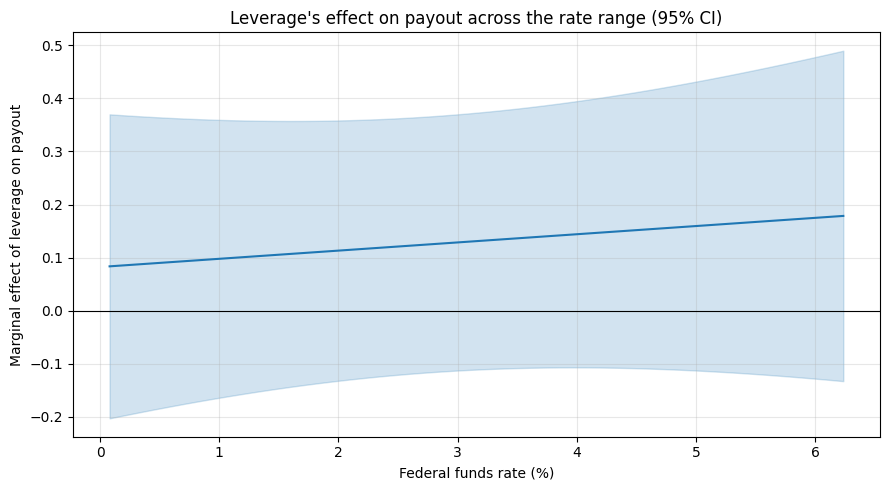

In [13]:
# continuous-regime variant + marginal-effect plot across the rate range
panel["lev_x_ffr"] = panel["lev"] * panel["ffr"]
res_cont = fit_panel(panel, "payout", ["lev", "lev_x_ffr"] + BASE_CONTROLS,
                     title="Continuous regime: payout ~ lev + lev x FFR + controls (two-way FE)")
if res_cont is not None and "lev_x_ffr" in getattr(res_cont, "params", {}):
    rr = np.linspace(panel["ffr"].min(), panel["ffr"].max(), 50)
    pts = [lincom(res_cont, {"lev": 1, "lev_x_ffr": r}) for r in rr]
    me = np.array([p[0] for p in pts]); se = np.array([p[1] for p in pts])
    plt.figure(); plt.plot(rr, me, color="tab:blue")
    plt.fill_between(rr, me - 1.96 * se, me + 1.96 * se, alpha=.2, color="tab:blue")
    plt.axhline(0, color="k", lw=.8)
    plt.xlabel("Federal funds rate (%)"); plt.ylabel("Marginal effect of leverage on payout")
    plt.title("Leverage's effect on payout across the rate range (95% CI)")
    plt.tight_layout(); plt.savefig(OUTDIR / "fig_marginal_effect.png", dpi=150); plt.show()

## 8 · Asset tangibility as a moderator — H3  <span style="color:gray">(§6.4)</span>

In [14]:
if panel["tangibility"].notna().any():
    panel["lev_x_tang"] = panel["lev"] * panel["tangibility"]
    panel["high_x_tang"] = panel["high_rate"] * panel["tangibility"]
    panel["lev_x_high_x_tang"] = panel["lev"] * panel["high_rate"] * panel["tangibility"]
    # A triple interaction needs every lower-order term, including the tangibility main effect.
    # (high_rate alone is absorbed by the year fixed effects.)
    H3_REGS = ["lev", "tangibility", "lev_x_high", "lev_x_tang", "high_x_tang", "lev_x_high_x_tang"]
    res_h3 = fit_panel(panel, "payout", H3_REGS + BASE_CONTROLS,
        title="H3: triple interaction lev x HighRate x tangibility (two-way FE)")

    # Variant: time-invariant industry tangibility (mean over non-break years) = a structural trait.
    # Its main effect is absorbed by the industry fixed effects; the interactions are identified.
    panel["tang_ind"] = panel.groupby("industry")["tangibility"].transform("mean")
    panel["lev_x_tangI"] = panel["lev"] * panel["tang_ind"]
    panel["high_x_tangI"] = panel["high_rate"] * panel["tang_ind"]
    panel["lev_x_high_x_tangI"] = panel["lev"] * panel["high_rate"] * panel["tang_ind"]
    H3I_REGS = ["lev", "tang_ind", "lev_x_high", "lev_x_tangI", "high_x_tangI", "lev_x_high_x_tangI"]
    res_h3_ti = fit_panel(panel, "payout", H3I_REGS + BASE_CONTROLS,
        title="H3 variant: time-invariant industry tangibility (two-way FE)")

    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    print("\n--- lev x HighRate by tangibility tercile ---")
    for g in ["low", "high"]:
        sub = panel[panel.tang_grp == g]
        if sub["year"].nunique() >= 3:
            fit_panel(sub, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"Tangibility = {g}")
else:
    print("H3 inactive: no tangibility.")

=== H3: triple interaction lev x HighRate x tangibility (two-way FE) ===
obs=1787  industries=134  years=24
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
const                 0.6788     0.2655     2.5562     0.0107      0.1579      1.1996
lev                   0.0873     0.2321     0.3761     0.7069     -0.3679      0.5425
tangibility          -0.0871     0.0282    -3.0841     0.0021     -0.1425     -0.0317
lev_x_high            0.0264     0.2722     0.0971     0.9227     -0.5074      0.5603
lev_x_tang           -0.0278     0.1102    -0.2526     0.8006     -0.2441      0.1884
high_x_tang           0.0462     0.0286     1.6171     0.1061     -0.0098      0.1022
lev_x_high_x_tang    -0.0542     0.1428    -0.3794     0.7044     -0.3342      0.2259
roe                  -0.4983    

                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.4104     0.2372     1.7303     0.0838     -0.0548      0.8755
lev                   -0.2151     0.4041    -0.5324     0.5945     -1.0076      0.5773
lev_x_high             0.1893     0.3894     0.4861     0.6270     -0.5744      0.9530
lev_x_tangI            0.2582     0.3195     0.8081     0.4191     -0.3684      0.8848
high_x_tangI           0.0441     0.0583     0.7565     0.4495     -0.0703      0.1585
lev_x_high_x_tangI    -0.1506     0.2742    -0.5494     0.5828     -0.6884      0.3871
roe                   -0.5339     0.1259    -4.2399     0.0000     -0.7809     -0.2869
tax                   -0.2801     0.1883    -1.4877     0.1370     -0.6493      0.0892
size                   0.0007     0.0204   


## 8b · Dividend smoothing: Lintner partial adjustment and H1 in change form  <span style="color:gray">(§6.4, §7.1)</span>

**Lintner (1956).** Firms move dividends only part of the way toward a target share of earnings each year:
$\Delta D_{it} = \text{SOA}\,(r\,E_{it} - D_{i,t-1})$. Scaling by last year's market cap (so large and small
industries are comparable) gives

$$\frac{\Delta D_{it}}{MC_{i,t-1}}=\beta_E\,\frac{E_{it}}{MC_{i,t-1}}+\beta_D\,\frac{D_{i,t-1}}{MC_{i,t-1}}+\alpha_i+\delta_t+\varepsilon_{it},
\qquad \text{SOA}=-\beta_D,\quad r=\beta_E/\text{SOA}.$$

A low speed of adjustment (SOA) means sticky dividends, the proposed explanation for the null in §7.

**H1 as stated is about changes** ("industries with higher leverage *reduce* dividends more during rate-hiking
cycles"). Adding last year's leverage and its interaction with the regime to the change equation tests it directly:
H1 ⇔ $\text{lev}_{t-1}\times\text{Regime}<0$. Three regime definitions: the high-rate dummy, hiking years
(fed funds up ≥ 25bp), and the continuous change in the fed funds rate.

**Estimation notes.** With a lagged dependent variable, industry fixed effects bias the persistence coefficient
downward (Nickell, 1981), so the within estimator *overstates* SOA, while pooled OLS without industry effects
*understates* it; the true value lies between the two (Bond, 2002). Dollar dividends and net income come from
`divfcfe` (net income excluded in the years flagged by the §2 cross-file check); industries merged by the rename
map are summed. Lags require the previous calendar year (no gap bridging), and 2013 is dropped from these models because
the 2012→2013 change crosses Damodaran's reclassification: industry dividends jump by a median 42% that year versus
10–20% in other years, which reflects firms moving between industries rather than dividend decisions.


In [15]:

# ---- dollar frame ($m): dividends & net income (divfcfe), market cap (divfund).
#      Industries merged by the rename map are SUMMED here (the ratio panel averages them).
usd = raw[["industry", "year", "div_usd", "ni_usd", "mktcap"]].copy()
usd["industry"] = usd["industry"].replace(INDUSTRY_RENAME)
usd = (usd[usd["industry"].isin(panel["industry"])]
       .groupby(["industry", "year"], as_index=False)[["div_usd", "ni_usd", "mktcap"]].sum(min_count=1))
L = usd.merge(panel[["industry", "year", "payout", "lev", "roe", "tax", "size",
                     "high_rate", "ffr_change", "in_core"]], on=["industry", "year"], how="inner")

# gap-safe one-year lags: an industry missing year t-1 gets no lag
_lag = L[["industry", "year", "div_usd", "mktcap", "lev", "payout"]].copy(); _lag["year"] += 1
L = L.merge(_lag.rename(columns={c: c + "_l1" for c in ["div_usd", "mktcap", "lev", "payout"]}),
            on=["industry", "year"], how="left")
L["dD"] = (L["div_usd"] - L["div_usd_l1"]) / L["mktcap_l1"]      # change in dividends
L["E"]  = L["ni_usd"] / L["mktcap_l1"]                            # current earnings
L["Dl"] = L["div_usd_l1"] / L["mktcap_l1"]                        # last year's dividends
L.loc[L["year"].isin(DIVFCFE_BAD_YEARS), ["dD", "E"]] = np.nan    # net income unreliable there (§2 check)
L.loc[L["year"] == RECLASS_YEAR, ["dD", "payout_l1", "lev_l1"]] = np.nan   # t-1 -> t crosses the 2013 reclassification
L = winsorize(L, ["dD", "E", "Dl"])
L["hike"] = (L["ffr_change"] >= HIKE_THRESHOLD).astype(int)
for a, b in [("E", "high_rate"), ("Dl", "high_rate"), ("lev_l1", "high_rate"),
             ("lev_l1", "hike"), ("lev_l1", "ffr_change")]:
    L[f"{a}_x_{b}"] = L[a] * L[b]
print("Hiking years (fed funds up >= %.2fpp):" % HIKE_THRESHOLD,
      sorted(int(y) for y in L.loc[L["hike"] == 1, "year"].unique()), "\n")

lint = {}
lint["L1_within"] = fit_panel(L, "dD", ["E", "Dl"], title="L1 Lintner, two-way FE (SOA upper bound)")
lint["L1_pooled"] = fit_panel(L, "dD", ["E", "Dl"], entity=False,
                              title="L1 Lintner, year FE only (SOA lower bound)")
lint["L2_regime"] = fit_panel(L, "dD", ["E", "Dl", "E_x_high_rate", "Dl_x_high_rate"],
                              title="L2 Smoothing by regime")
H1C = ["E", "Dl", "lev_l1"]
lint["L3_high"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_high_rate"], title="L3 H1 in change form: high-rate years")
lint["L3_hike"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_hike"], title="L3 H1 in change form: hiking years")
lint["L3_dffr"]  = fit_panel(L, "dD", H1C + ["lev_l1_x_ffr_change"], title="L3 H1 in change form: change in FFR")
lint["L3_core"]  = fit_panel(L[L["in_core"]], "dD", H1C + ["lev_l1_x_high_rate"],
                             title="L3 H1 in change form: high-rate years, stable core")
lint["R_within"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, title="Payout-ratio persistence, two-way FE")
lint["R_pooled"] = fit_panel(L, "payout", ["payout_l1"] + BASE_CONTROLS, entity=False,
                             title="Payout-ratio persistence, year FE only")

# ---- summary
soa_hi, soa_lo = -lint["L1_within"].params["Dl"], -lint["L1_pooled"].params["Dl"]
target = lint["L1_pooled"].params["E"] / soa_lo
rho_lo, rho_hi = lint["R_within"].params["payout_l1"], lint["R_pooled"].params["payout_l1"]
print(f"\nSpeed of adjustment of dividends: between {soa_lo:.2f} and {soa_hi:.2f} per year "
      f"(dividend persistence {1 - soa_hi:.2f}-{1 - soa_lo:.2f}); target payout (pooled) = {target:.2f}")
print(f"Persistence of the payout RATIO: {rho_lo:.2f}-{rho_hi:.2f}")

KEYS = [("L1_within", "Dl", "Lintner, two-way FE"), ("L1_pooled", "Dl", "Lintner, year FE only"),
        ("L2_regime", "Dl_x_high_rate", "Smoothing x high-rate"), ("L2_regime", "E_x_high_rate", "Earnings x high-rate"),
        ("L3_high", "lev_l1_x_high_rate", "H1 change form: high-rate"),
        ("L3_hike", "lev_l1_x_hike", "H1 change form: hiking year"),
        ("L3_dffr", "lev_l1_x_ffr_change", "H1 change form: change in FFR"),
        ("L3_core", "lev_l1_x_high_rate", "H1 change form: high-rate, stable core"),
        ("R_within", "payout_l1", "Payout-ratio persistence, two-way FE"),
        ("R_pooled", "payout_l1", "Payout-ratio persistence, year FE only")]
lint_tbl = pd.DataFrame([{"model": lab, "term": t, "coef": lint[k].params[t], "se": lint[k].std_errors[t],
                          "p": lint[k].pvalues[t], "N": int(lint[k].nobs)} for k, t, lab in KEYS]).round(4)
lint_tbl.to_csv(OUTDIR / "tab_lintner.csv", index=False)
lint_tbl


Hiking years (fed funds up >= 0.25pp): [2000, 2005, 2006, 2016, 2017, 2018, 2019, 2022, 2023] 

=== L1 Lintner, two-way FE (SOA upper bound) ===
obs=1771  industries=131  years=23


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0050     0.0005     10.518     0.0000      0.0040      0.0059
E              0.0259     0.0066     3.8983     0.0001      0.0129      0.0389
Dl            -0.3624     0.0278    -13.012     0.0000     -0.4170     -0.3077
R2(within): 0.162
=== L1 Lintner, year FE only (SOA lower bound) ===
obs=1771  industries=131  years=23
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0011     0.0004     3.0345     0.0024      0.0004      0.0018
E              0.0268     0.0052     5.1063     0.0000      0.0165      0.0371
Dl            -0.0943     0

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
const              0.0050     0.0005     10.623     0.0000      0.0041      0.0060
E                  0.0244     0.0076     3.2021     0.0014      0.0095      0.0394
Dl                -0.3744     0.0293    -12.780     0.0000     -0.4319     -0.3170
E_x_high_rate      0.0044     0.0123     0.3557     0.7221     -0.0197      0.0285
Dl_x_high_rate     0.0336     0.0391     0.8594     0.3903     -0.0431      0.1102
R2(within): 0.155
=== L3 H1 in change form: high-rate years ===
obs=1771  industries=131  years=23
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------

                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
const             0.0039     0.0007     5.5430     0.0000      0.0025      0.0052
E                 0.0273     0.0064     4.2404     0.0000      0.0147      0.0400
Dl               -0.3834     0.0299    -12.839     0.0000     -0.4419     -0.3248
lev_l1            0.0049     0.0031     1.5592     0.1191     -0.0013      0.0110
lev_l1_x_hike     0.0015     0.0023     0.6669     0.5050     -0.0029      0.0060
R2(within): 0.166
=== L3 H1 in change form: change in FFR ===
obs=1771  industries=131  years=23
                                  Parameter Estimates                                  
                     Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------

=== L3 H1 in change form: high-rate years, stable core ===
obs=1026  industries=46  years=23
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  0.0040     0.0009     4.6617     0.0000      0.0023      0.0056
E                      0.0305     0.0058     5.2473     0.0000      0.0191      0.0419
Dl                    -0.3456     0.0325    -10.631     0.0000     -0.4094     -0.2818
lev_l1                 0.0020     0.0036     0.5561     0.5783     -0.0050      0.0090
lev_l1_x_high_rate     0.0022     0.0030     0.7314     0.4647     -0.0038      0.0082
R2(within): 0.163
=== Payout-ratio persistence, two-way FE ===
obs=1796  industries=132  years=25


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4808     0.2500     1.9230     0.0547     -0.0096      0.9713
payout_l1      0.1352     0.0364     3.7100     0.0002      0.0637      0.2066
roe           -0.4751     0.1308    -3.6312     0.0003     -0.7318     -0.2185
tax           -0.2992     0.2018    -1.4828     0.1383     -0.6950      0.0966
size          -0.0057     0.0216    -0.2628     0.7927     -0.0480      0.0366
R2(within): 0.067
=== Payout-ratio persistence, year FE only ===
obs=1796  industries=132  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.1151     0.113

,model,term,coef,se,p,N
0,"Lintner, two-way FE",Dl,-0.3624,0.0278,0.0000,1771
1,"Lintner, year FE only",Dl,-0.0943,0.0270,0.0005,1771
2,Smoothing x high-rate,Dl_x_high_rate,0.0336,0.0391,0.3903,1771
3,Earnings x high-rate,E_x_high_rate,0.0044,0.0123,0.7221,1771
4,H1 change form: high-rate,lev_l1_x_high_rate,0.0016,0.0039,0.6751,1771
5,H1 change form: hiking year,lev_l1_x_hike,0.0015,0.0023,0.5050,1771
6,H1 change form: change in FFR,lev_l1_x_ffr_change,0.0006,0.0009,0.5179,1771
7,"H1 change form: high-rate, stable core",lev_l1_x_high_rate,0.0022,0.0030,0.4647,1026
8,"Payout-ratio persistence, two-way FE",payout_l1,0.1352,0.0364,0.0002,1796
9,"Payout-ratio persistence, year FE only",payout_l1,0.4092,0.0498,0.0000,1796


## 9 · Robustness  <span style="color:gray">(§5.5, §6.5)</span>

Alt payout measures · **stable-core sample** (immune to the 2013 reclassification) · **post-2022 regime**
definition · two-way clustering · ex-COVID · lagged leverage · **industry FE only with macro controls** ·
**ROE mechanical-link check** · **backward elimination of insignificant controls** · **H3 in the stable core**.

In [16]:
robust = {}
# (a) stable core
print(">>> Stable core (industries present >= MIN_YEARS_CORE years)")
robust["core"] = fit_panel(panel[panel.in_core], "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                           title=f"Stable core ({len(CORE)} industries)")
# (b) post-2022 regime definition
pp = panel.copy(); pp["lev_x_high"] = pp["lev"] * pp["high_rate_post2022"]
print("\n>>> Post-2022 binary regime")
robust["post2022"] = fit_panel(pp, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                               title="Regime = post-2022 binary")
# (c) alternative payout
for dv_alt in ["div_to_fcfe", "totpayout_ni"]:
    if dv_alt in panel and panel[dv_alt].notna().any():
        print(f"\n>>> Alt payout: {dv_alt}")
        robust[dv_alt] = fit_panel(panel, dv_alt, ["lev", "lev_x_high"] + BASE_CONTROLS, title=f"DV={dv_alt}")
# (d) two-way clustering
print("\n>>> Two-way clustered SE")
robust["twoway"] = fit_panel(panel, "payout", ["lev", "lev_x_high"] + BASE_CONTROLS,
                             cluster_time=True, title="Two-way clustering")
# (e) ex-COVID
print("\n>>> Excluding COVID years", COVID_YEARS)
robust["noCovid"] = fit_panel(panel[~panel.year.isin(COVID_YEARS)], "payout",
                              ["lev", "lev_x_high"] + BASE_CONTROLS, title="Excl. COVID")
# (f) lagged leverage
pl = panel.sort_values(["industry", "year"]).copy()
pl["lev_lag"] = pl.groupby("industry")["lev"].shift(1)
pl["lev_lag_x_high"] = pl["lev_lag"] * pl["high_rate"]
if pl["lev_lag"].notna().any():
    print("\n>>> Lagged leverage")
    robust["lagged"] = fit_panel(pl, "payout", ["lev_lag", "lev_lag_x_high"] + BASE_CONTROLS,
                                 title="Lagged leverage")

# (g) industry FE only: the macro controls and the regime level are estimable here (no year FE),
#     so errors are clustered by industry AND year.
print("\n>>> Industry FE only, with macro controls and the regime level")
robust["indFE_macro"] = fit_panel(panel, "payout",
    ["lev", "high_rate", "lev_x_high"] + BASE_CONTROLS + MACRO_CONTROLS,
    time=False, cluster_time=True, title="Industry FE + macro controls (no year FE), two-way clustered")

# (h) ROE mechanical-link check: payout = D/NI and ROE = NI/E share net income.
print("\n>>> ROE mechanical-link check: interaction model without ROE")
robust["noROE"] = fit_panel(panel, "payout", ["lev", "lev_x_high", "tax", "size"],
                            title="Interaction without ROE")
if robust.get("div_to_fcfe") is not None and "roe" in robust["div_to_fcfe"].params:
    r_ = robust["div_to_fcfe"]
    print(f"ROE with Dividends/FCFE as DV (no net income in the ratio): "
          f"{r_.params['roe']:+.3f} (p={r_.pvalues['roe']:.3f})")

# (i) Backward elimination a posteriori: repeatedly drop the least significant CONTROL with p > 0.05.
#     The hypothesis terms (lev, lev_x_high) are never dropped.
print("\n>>> Backward elimination of insignificant controls (a posteriori, 5%)")
keep = list(BASE_CONTROLS)
while keep:
    r_ = fit_panel(panel, "payout", ["lev", "lev_x_high"] + keep, title=f"Elimination step: controls={keep}")
    pv = r_.pvalues[keep]
    if pv.max() <= 0.05:
        break
    print(f"   -> dropping {pv.idxmax()} (p={pv.max():.3f})\n")
    keep.remove(pv.idxmax())
robust["elimination"] = r_
print("Controls retained by elimination:", keep)

# (j) H3 in the stable core
if "res_h3" in globals():
    print("\n>>> H3 in the stable core")
    robust["H3_core"] = fit_panel(panel[panel.in_core], "payout", H3_REGS + BASE_CONTROLS,
                                  title="H3: stable core")


>>> Stable core (industries present >= MIN_YEARS_CORE years)
=== Stable core (46 industries) ===
obs=1153  industries=46  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.3035     0.2872     1.0568     0.2908     -0.2600      0.8670
lev            0.1692     0.1793     0.9437     0.3456     -0.1826      0.5210
lev_x_high    -0.0203     0.1747    -0.1164     0.9074     -0.3631      0.3225
roe           -0.4814     0.1200    -4.0114     0.0001     -0.7169     -0.2459
tax           -0.1738     0.2063    -0.8424     0.3998     -0.5786      0.2310
size           0.0117     0.0249     0.4705     0.6381     -0.0371      0.0605
R2(within): 0.046

>>> Post-2022 binary regime
=== Regime = post-2022 binary ===
obs=2015  industries=142  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4890     0.2297     2.1284     0.0334      0.0384      0.9395
lev            0.1546     0.1195     1.2939     0.1959     -0.0797      0.3889
lev_x_high    -0.3026     0.2065    -1.4652     0.1430     -0.7075      0.1024
roe           -0.5310     0.1276    -4.1602     0.0000     -0.7814     -0.2807
tax           -0.2893     0.1852    -1.5620     0.1185     -0.6526      0.0740
size          -0.0039     0.0200    -0.1969     0.8439     -0.0432      0.0353
R2(within): 0.029

>>> Alt payout: div_to_fcfe
=== DV=div_to_fcfe ===
obs=1946  industries=142  years=25


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -0.4125     1.0265    -0.4019     0.6878     -2.4259      1.6008
lev           -0.9960     0.5718    -1.7418     0.0817     -2.1174      0.1255
lev_x_high     0.6273     0.6392     0.9815     0.3265     -0.6263      1.8809
roe            0.2678     0.3399     0.7879     0.4308     -0.3989      0.9345
tax           -1.2705     1.2752    -0.9963     0.3192     -3.7715      1.2305
size           0.0962     0.0818     1.1760     0.2397     -0.0642      0.2567
R2(within): -0.001

>>> Alt payout: totpayout_ni
=== DV=totpayout_ni ===
obs=997  industries=91  years=13


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          1.1198     1.8995     0.5895     0.5557     -2.6082      4.8477
lev           -0.1670     1.3646    -0.1224     0.9026     -2.8451      2.5111
lev_x_high    -1.6472     2.0068    -0.8208     0.4120     -5.5858      2.2913
roe            0.7141     0.5564     1.2834     0.1997     -0.3779      1.8061
tax            0.5473     1.9263     0.2841     0.7764     -3.2334      4.3279
size          -0.0308     0.1509    -0.2044     0.8381     -0.3270      0.2653
R2(within): 0.006

>>> Two-way clustered SE
=== Two-way clustering ===
obs=2015  industries=142  years=27


                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4262     0.2563     1.6628     0.0965     -0.0765      0.9288
lev            0.1240     0.1622     0.7646     0.4446     -0.1941      0.4422
lev_x_high    -0.0112     0.1460    -0.0769     0.9387     -0.2976      0.2752
roe           -0.5322     0.1670    -3.1867     0.0015     -0.8597     -0.2046
tax           -0.2841     0.1720    -1.6513     0.0988     -0.6215      0.0533
size           0.0011     0.0218     0.0499     0.9602     -0.0417      0.0439


R2(within): 0.046

>>> Excluding COVID years [2020, 2021]
=== Excl. COVID ===
obs=1862  industries=142  years=25
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.3352     0.2581     1.2989     0.1941     -0.1710      0.8414
lev            0.1833     0.1392     1.3165     0.1882     -0.0898      0.4563
lev_x_high    -0.0968     0.1452    -0.6666     0.5051     -0.3816      0.1880
roe           -0.6913     0.1631    -4.2392     0.0000     -1.0112     -0.3715
tax           -0.3810     0.1860    -2.0482     0.0407     -0.7458     -0.0162
size           0.0115     0.0223     0.5177     0.6047     -0.0322      0.0553
R2(within): 0.073

>>> Lagged leverage
=== Lagged leverage ===
obs=1881  industries=132  years=26
                               Parameter Estimates                           

                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           0.4945     0.2609     1.8954     0.0582     -0.0172      1.0061
lev             0.1653     0.1587     1.0421     0.2975     -0.1458      0.4765
high_rate      -0.0040     0.0430    -0.0920     0.9267     -0.0883      0.0804
lev_x_high     -0.0895     0.1440    -0.6219     0.5341     -0.3719      0.1928
roe            -0.4759     0.1617    -2.9432     0.0033     -0.7930     -0.1588
tax            -0.7810     0.2374    -3.2897     0.0010     -1.2466     -0.3154
size           -0.0006     0.0200    -0.0295     0.9765     -0.0398      0.0386
gdp_growth      0.0132     0.0096     1.3703     0.1708     -0.0057      0.0321
cred_spread    -0.0118     0.0557    -0.2124     0.8318     -0.1211      0.0974
R2(within): 0.065

>>> ROE mechanical-li

                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.4396     0.0538     8.1757     0.0000      0.3342      0.5451
lev            0.1213     0.1510     0.8029     0.4222     -0.1749      0.4175
lev_x_high    -0.0118     0.1395    -0.0844     0.9328     -0.2854      0.2618
roe           -0.5314     0.1247    -4.2630     0.0000     -0.7759     -0.2869
tax           -0.2837     0.1867    -1.5196     0.1288     -0.6498      0.0824
R2(within): 0.046
   -> dropping tax (p=0.129)

=== Elimination step: controls=['roe'] ===
obs=2015  industries=142  years=27
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const

In [17]:

# Robustness summary (Appendix C): the regime-interaction term in every specification
KEY = {"lagged": "lev_lag_x_high", "H3_core": "lev_x_high_x_tang"}
LABEL = {"core": "Stable core", "post2022": "Regime = post-2022", "div_to_fcfe": "DV = Dividends/FCFE",
         "totpayout_ni": "DV = (Div+Buybacks)/NI", "twoway": "Two-way clustered SE", "noCovid": "Excl. 2020-21",
         "lagged": "Lagged leverage", "indFE_macro": "Industry FE + macro controls",
         "noROE": "Without ROE", "elimination": "Backward elimination", "H3_core": "H3 triple term, stable core"}
rows = [{"specification": "Main (two-way FE)", "term": "lev_x_high",
         "coef": res_int.params["lev_x_high"], "se": res_int.std_errors["lev_x_high"],
         "p": res_int.pvalues["lev_x_high"], "N": int(res_int.nobs)}]
for k, r in robust.items():
    if r is None:
        continue
    term = KEY.get(k, "lev_x_high")
    if term in r.params:
        rows.append({"specification": LABEL.get(k, k), "term": term, "coef": r.params[term],
                     "se": r.std_errors[term], "p": r.pvalues[term], "N": int(r.nobs)})
rob_tbl = pd.DataFrame(rows).round(4)
rob_tbl.to_csv(OUTDIR / "tab_robustness_summary.csv", index=False)
rob_tbl


,specification,term,coef,se,p,N
0,Main (two-way FE),lev_x_high,-0.0112,0.1381,0.9352,2015
1,Stable core,lev_x_high,-0.0203,0.1747,0.9074,1153
2,Regime = post-2022,lev_x_high,-0.3026,0.2065,0.1430,2015
3,DV = Dividends/FCFE,lev_x_high,0.6273,0.6392,0.3265,1946
4,DV = (Div+Buybacks)/NI,lev_x_high,-1.6472,2.0068,0.4120,997
5,Two-way clustered SE,lev_x_high,-0.0112,0.1460,0.9387,2015
6,Excl. 2020-21,lev_x_high,-0.0968,0.1452,0.5051,1862
7,Lagged leverage,lev_lag_x_high,-0.0238,0.1472,0.8714,1881
8,Industry FE + macro controls,lev_x_high,-0.0895,0.1440,0.5341,2015
9,Without ROE,lev_x_high,-0.0532,0.1361,0.6960,2029


### 9b · How large an effect can we rule out?  <span style="color:gray">(§6.5, §7.1)</span>

A non-significant estimate is only informative if the test could have detected an effect of economically
relevant size. For the H2 interaction in each payout-ratio specification the table reports:

- the **95% confidence interval** of β₂: regime effects outside it are rejected at 5%;
- the **minimum detectable effect** at 5% significance and 80% power, MDE = (z₀.₉₇₅ + z₀.₈₀)·SE ≈ 2.8·SE
  (Bloom, 1995): the smallest true β₂ the test would detect four times out of five;
- the smallest **equivalence margin** δ for which two one-sided tests (TOST; Schuirmann, 1987; Lakens, 2017)
  reject |β₂| ≥ δ at 5%, i.e. the largest absolute bound of the 90% interval.

Coefficients are converted into payout-ratio units for a one-standard-deviation difference in leverage
(overall SD, i.e. across industries, as H2 compares more and less levered industries; the within-industry SD
is shown for reference). `EQUIV_MARGIN` in the configuration sets the effect regarded as economically
negligible for the yes/no equivalence column.

In [18]:
from scipy import stats
Z95, Z90, Z80 = stats.norm.ppf(0.975), stats.norm.ppf(0.95), stats.norm.ppf(0.80)
SD_LEV   = float(sd_decomp.loc["lev", "sd_overall"])   # across industries (used for the payout conversion)
SD_LEV_W = float(sd_decomp.loc["lev", "sd_within"])    # within industries (reference)
MEAN_PAYOUT = float(panel["payout"].mean())

PAYOUT_SPECS = ["Main (two-way FE)", "Stable core", "Regime = post-2022", "Two-way clustered SE",
                "Excl. 2020-21", "Lagged leverage", "Industry FE + macro controls", "Without ROE",
                "Backward elimination"]
pw = rob_tbl[rob_tbl["specification"].isin(PAYOUT_SPECS)][["specification", "coef", "se", "N"]].copy()
lo95, hi95 = pw["coef"] - Z95 * pw["se"], pw["coef"] + Z95 * pw["se"]
pw["ci95"] = [f"[{a:+.3f}, {b:+.3f}]" for a, b in zip(lo95, hi95)]
pw["mde80"] = (Z95 + Z80) * pw["se"]                                    # Bloom (1995)
pw["tost_margin"] = np.maximum((pw["coef"] - Z90 * pw["se"]).abs(), (pw["coef"] + Z90 * pw["se"]).abs())
pw["ci95_bound_payout"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV   # largest effect not rejected
pw["mde80_payout"] = pw["mde80"] * SD_LEV
pw["tost_margin_payout"] = pw["tost_margin"] * SD_LEV
pw["ci95_bound_payout_within"] = np.maximum(lo95.abs(), hi95.abs()) * SD_LEV_W
pw["equivalent_at_margin"] = pw["tost_margin_payout"] <= EQUIV_MARGIN
power_tbl = pw.round(4)
power_tbl.to_csv(OUTDIR / "tab_power_bounds.csv", index=False)

m = power_tbl.iloc[0]
print(f"SD of leverage: overall {SD_LEV:.3f}, within-industry {SD_LEV_W:.3f}; mean payout {MEAN_PAYOUT:.3f}\n")
print(f"Main specification, beta2 = {m.coef:+.4f} (SE {m.se:.4f}), 95% CI {m.ci95}:")
print(f"  - rules out regime effects above {m.ci95_bound_payout:.3f} payout per 1-SD leverage "
      f"({m.ci95_bound_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - 80% power to detect |beta2| >= {m.mde80:.3f}, i.e. {m.mde80_payout:.3f} payout per 1-SD leverage "
      f"({m.mde80_payout / MEAN_PAYOUT:.0%} of the mean payout)")
print(f"  - equivalence (TOST, 5%) holds for any margin >= {m.tost_margin_payout:.3f} payout per 1-SD leverage; "
      f"at EQUIV_MARGIN = {EQUIV_MARGIN}: {'equivalent' if m.equivalent_at_margin else 'not shown'}\n")
power_tbl

SD of leverage: overall 0.138, within-industry 0.076; mean payout 0.349

Main specification, beta2 = -0.0112 (SE 0.1381), 95% CI [-0.282, +0.259]:
  - rules out regime effects above 0.039 payout per 1-SD leverage (11% of the mean payout)
  - 80% power to detect |beta2| >= 0.387, i.e. 0.053 payout per 1-SD leverage (15% of the mean payout)
  - equivalence (TOST, 5%) holds for any margin >= 0.033 payout per 1-SD leverage; at EQUIV_MARGIN = 0.05: equivalent



,specification,coef,se,N,ci95,mde80,tost_margin,ci95_bound_payout,mde80_payout,tost_margin_payout,ci95_bound_payout_within,equivalent_at_margin
0,Main (two-way FE),-0.0112,0.1381,2015,"[-0.282, +0.259]",0.3869,0.2384,0.0389,0.0534,0.0329,0.0214,True
1,Stable core,-0.0203,0.1747,1153,"[-0.363, +0.322]",0.4894,0.3077,0.0501,0.0675,0.0425,0.0276,True
2,Regime = post-2022,-0.3026,0.2065,2015,"[-0.707, +0.102]",0.5785,0.6423,0.0976,0.0798,0.0886,0.0538,False
5,Two-way clustered SE,-0.0112,0.1460,2015,"[-0.297, +0.275]",0.4090,0.2513,0.0410,0.0564,0.0347,0.0226,True
6,Excl. 2020-21,-0.0968,0.1452,1862,"[-0.381, +0.188]",0.4068,0.3356,0.0526,0.0561,0.0463,0.0290,True
7,Lagged leverage,-0.0238,0.1472,1881,"[-0.312, +0.265]",0.4124,0.2659,0.0431,0.0569,0.0367,0.0237,True
8,Industry FE + macro controls,-0.0895,0.1440,2015,"[-0.372, +0.193]",0.4034,0.3264,0.0513,0.0557,0.0450,0.0283,True
9,Without ROE,-0.0532,0.1361,2029,"[-0.320, +0.214]",0.3813,0.2771,0.0442,0.0526,0.0382,0.0243,True
10,Backward elimination,-0.0028,0.1384,2015,"[-0.274, +0.268]",0.3877,0.2304,0.0378,0.0535,0.0318,0.0208,True


## 10 · Results table, hypothesis verdicts, proxy robustness & Appendix A

In [19]:
def tidy(res, name):
    if res is None or not hasattr(res, "params"): return None
    out = {}
    for k in res.params.index:
        if k == "const": continue
        b, p = res.params[k], res.pvalues[k]
        star = "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""
        se = res.std_errors[k] if hasattr(res, "std_errors") else res.bse[k]
        out[k] = f"{b:.3f}{star} ({se:.3f})"
    out["N"] = int(res.nobs); out["R2_within"] = round(float(getattr(res, "rsquared_within", np.nan)), 3)
    return pd.Series(out, name=name)

reg_table = pd.concat([tidy(res_base, "Baseline"), tidy(res_int, "Interaction"),
                       tidy(res_cont, "Continuous"),
                       tidy(res_h3, "H3") if "res_h3" in globals() else None,
                       tidy(res_h3_ti, "H3 (time-inv. tang.)") if "res_h3_ti" in globals() else None],
                      axis=1).fillna("")
reg_table.to_csv(OUTDIR / "tab_regressions_combined.csv")
try:
    open(OUTDIR / "tab_regressions_combined.tex", "w").write(reg_table.to_latex(escape=True))
except Exception as e:
    print("LaTeX skipped:", e)
print("estimate (clustered SE); * .10  ** .05  *** .01")
reg_table

estimate (clustered SE); * .10  ** .05  *** .01


,Baseline,Interaction,Continuous,H3,H3 (time-inv. tang.)
lev,0.120 (0.124),0.124 (0.140),0.082 (0.147),0.087 (0.232),-0.215 (0.404)
roe,-0.533*** (0.128),-0.532*** (0.128),-0.536*** (0.128),-0.498*** (0.137),-0.534*** (0.126)
tax,-0.283 (0.186),-0.284 (0.188),-0.280 (0.187),-0.300 (0.202),-0.280 (0.188)
size,0.001 (0.021),0.001 (0.021),0.002 (0.021),-0.012 (0.023),0.001 (0.020)
N,2015,2015,2015,1787,2007
R2_within,0.046,0.046,0.044,0.044,0.033
lev_x_high,,-0.011 (0.138),,0.026 (0.272),0.189 (0.389)
lev_x_ffr,,,0.015 (0.029),,
tangibility,,,,-0.087*** (0.028),
lev_x_tang,,,,-0.028 (0.110),


In [20]:
def verdicts():
    L = []
    if res_int is not None and "lev_x_high" in getattr(res_int, "params", {}):
        b1 = res_int.params["lev"]; b2 = res_int.params["lev_x_high"]; p2 = res_int.pvalues["lev_x_high"]
        hi = lincom(res_int, {"lev": 1, "lev_x_high": 1})
        L += [f"H1/H2  beta2 = {b2:+.4f} (p={p2:.3f}) -> " + ("SUPPORTED" if (b2 < 0 and p2 < .05) else "NOT supported at 5%"),
              f"        slope: low-rate {b1:+.3f} | high-rate {hi[0]:+.3f}  (H2 expects more negative when high)"]
        if "power_tbl" in globals():
            m_ = power_tbl.iloc[0]
            L += [f"        95% CI {m_.ci95}: rules out effects above {m_.ci95_bound_payout:.3f} payout per 1-SD "
                  f"leverage; MDE(80%) = {m_.mde80:.3f}"]
    if "res_h3" in globals() and res_h3 is not None and "lev_x_high_x_tang" in getattr(res_h3, "params", {}):
        b3 = res_h3.params["lev_x_high_x_tang"]; p3 = res_h3.pvalues["lev_x_high_x_tang"]
        L += ["", f"H3     triple = {b3:+.4f} (p={p3:.3f}) -> " + ("SUPPORTED" if (b3 > 0 and p3 < .05) else "NOT supported at 5%"),
              "        (H3 expects a POSITIVE triple term)"]
    return "\n".join(L)
txt = verdicts(); print(txt)
with open(OUTDIR / "hypothesis_verdicts.txt", "w") as _fh:
    _fh.write(txt)

H1/H2  beta2 = -0.0112 (p=0.935) -> NOT supported at 5%
        slope: low-rate +0.124 | high-rate +0.113  (H2 expects more negative when high)
        95% CI [-0.282, +0.259]: rules out effects above 0.039 payout per 1-SD leverage; MDE(80%) = 0.387

H3     triple = -0.0542 (p=0.704) -> NOT supported at 5%
        (H3 expects a POSITIVE triple term)


In [21]:
# H3 robustness to the tangibility proxy. Each proxy gets exactly the same cleaning as the main panel
# (industry rename map, collapsing merged industries, break years, winsorising), so the capex_deprec
# row must reproduce the main H3 estimate.
def tangibility_series(proxy):
    global TANGIBILITY_PROXY; saved = TANGIBILITY_PROXY; TANGIBILITY_PROXY = proxy
    fr = []
    for y in sorted(SOURCES["capex"]):
        cx = read_industry_sheet(SOURCES["capex"][y])
        fr.append(pd.DataFrame({"industry": cx["industry"], "year": y, "t_proxy": _tangibility(cx)}))
    TANGIBILITY_PROXY = saved
    t = pd.concat(fr, ignore_index=True)
    t["industry"] = t["industry"].replace(INDUSTRY_RENAME)
    t = t.groupby(["industry", "year"], as_index=False)["t_proxy"].mean()
    if proxy in DEPREC_PROXIES:
        t.loc[t["year"].isin(TANG_BREAK_YEARS), "t_proxy"] = np.nan
    return t

pr = []
for proxy in ["capex_deprec", "netcapex_sales", "invcap_sales"]:
    t = tangibility_series(proxy)
    d = panel.drop(columns=[c for c in ["t_proxy"] if c in panel]).merge(t, on=["industry", "year"], how="left")
    lo, hi = d["t_proxy"].quantile([WINSOR_P, 1 - WINSOR_P]); d["t_proxy"] = d["t_proxy"].clip(lo, hi)
    d["lxt"] = d.lev * d.t_proxy; d["hxt"] = d.high_rate * d.t_proxy
    d["lhxt"] = d.lev * d.high_rate * d.t_proxy
    regs = ["lev", "t_proxy", "lev_x_high", "lxt", "hxt", "lhxt"] + BASE_CONTROLS
    sub = d.dropna(subset=["payout"] + regs)
    if sub.year.nunique() >= 3 and HAVE_LM:
        import statsmodels.api as sm
        dd = sub.set_index(["industry", "year"])
        r = PanelOLS(dd["payout"], sm.add_constant(dd[regs]), entity_effects=True, time_effects=True,
                     drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        pr.append({"proxy": proxy, "years": f"{int(sub.year.min())}-{int(sub.year.max())} ({sub.year.nunique()})",
                   "triple_coef": round(r.params["lhxt"], 4), "se": round(r.std_errors["lhxt"], 4),
                   "p_value": round(r.pvalues["lhxt"], 3), "N": int(r.nobs)})
proxy_tbl = pd.DataFrame(pr); proxy_tbl.to_csv(OUTDIR / "tab_H3_proxy_robustness.csv", index=False)

# consistency check against the main H3 model
main = proxy_tbl.set_index("proxy").loc["capex_deprec"]
assert abs(main.triple_coef - round(res_h3.params["lev_x_high_x_tang"], 4)) < 1e-4 and main.N == int(res_h3.nobs), \
    "proxy loop does not reproduce the main H3 estimate"
print("Check OK: capex_deprec row reproduces the main H3 estimate.\n")
print("H3 triple-interaction under each tangibility proxy:"); proxy_tbl

Check OK: capex_deprec row reproduces the main H3 estimate.

H3 triple-interaction under each tangibility proxy:


,proxy,years,triple_coef,se,p_value,N
0,capex_deprec,1999-2025 (24),-0.0542,0.1428,0.704,1787
1,netcapex_sales,1999-2025 (24),-3.7622,2.1858,0.085,1787
2,invcap_sales,2001-2025 (25),-0.5320,0.1973,0.007,1867


In [22]:
# Appendix A — variable definitions
appendix_A = pd.DataFrame([
    ("payout", "Dependent (primary)", "Dividend payout ratio", "divfund"),
    ("div_to_fcfe", "Dependent (secondary)", "Dividends / FCFE", "divfcfe"),
    ("totpayout_ni", "Dependent (alt)", "(Dividends+Buybacks)/Net Income", "divfcfe (2015+)"),
    ("lev", "Key independent", "Market debt ratio D/(D+E)", "wacc"),
    ("tangibility", "Moderator (H3)", f"Proxy = {TANGIBILITY_PROXY}; missing in {TANG_BREAK_YEARS[0]}-{TANG_BREAK_YEARS[-1]}", "capex"),
    ("roe", "Control", "Return on equity", "divfund"),
    ("tax", "Control", "Effective tax rate", "wacc"),
    ("size", "Control", "log(Market Cap)", "divfund"),
    ("gdp_growth", "Macro control", "Real GDP growth % (absorbed by year FE; used in industry-FE-only spec)", "FRED GDPC1"),
    ("cred_spread", "Macro control", "BAA-AAA spread (absorbed by year FE; used in industry-FE-only spec)", "FRED BAA, AAA"),
    ("t10", "Descriptive", "10-year Treasury yield, annual avg", "FRED GS10"),
    ("high_rate", "Regime", f"1 if {'ffr>=%g%%'%FFR_THRESHOLD if HIGH_RATE_RULE=='threshold' else 'year>=2022'}", "FRED FEDFUNDS"),
    ("ffr", "Regime (cont.)", "Avg fed funds rate", "FRED FEDFUNDS"),
], columns=["variable", "role", "definition", "source"])
appendix_A.to_csv(OUTDIR / "appendix_A_variable_definitions.csv", index=False); appendix_A

,variable,role,definition,source
0,payout,Dependent (primary),Dividend payout ratio,divfund
1,div_to_fcfe,Dependent (secondary),Dividends / FCFE,divfcfe
2,totpayout_ni,Dependent (alt),(Dividends+Buybacks)/Net Income,divfcfe (2015+)
3,lev,Key independent,Market debt ratio D/(D+E),wacc
4,tangibility,Moderator (H3),Proxy = capex_deprec; missing in 2013-2015,capex
5,roe,Control,Return on equity,divfund
6,tax,Control,Effective tax rate,wacc
7,size,Control,log(Market Cap),divfund
8,gdp_growth,Macro control,Real GDP growth % (absorbed by year FE; used i...,FRED GDPC1
9,cred_spread,Macro control,BAA-AAA spread (absorbed by year FE; used in i...,"FRED BAA, AAA"


## 11 · Visual analysis  <span style="color:gray">(figures for Chapters 4 & 6)</span>

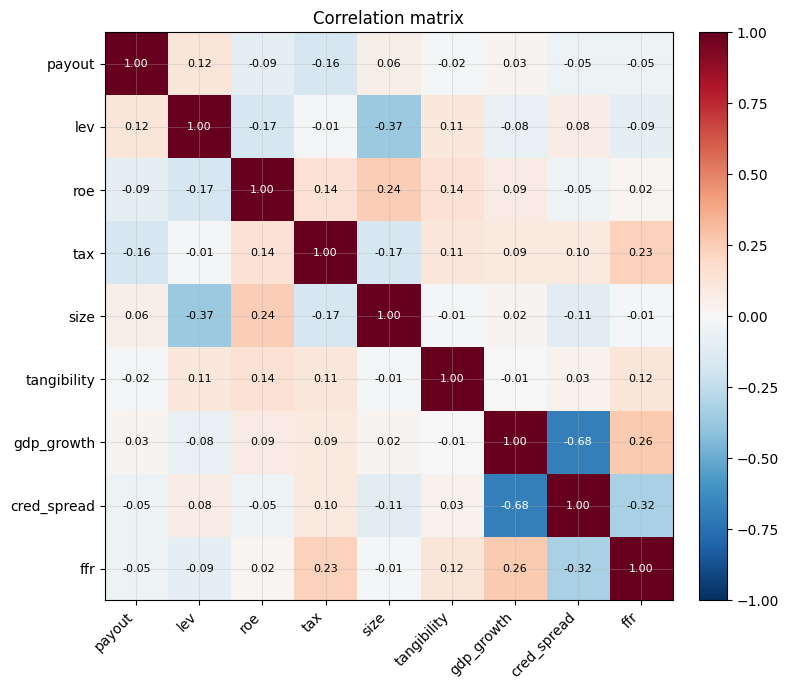

In [23]:
# Fig 1 — correlation heatmap
cv = [c for c in ["payout", "lev", "roe", "tax", "size", "tangibility",
                  "gdp_growth", "cred_spread", "ffr"] if c in panel and panel[c].notna().any()]
C = panel[cv].corr()
fig, ax = plt.subplots(figsize=(8, 7)); im = ax.imshow(C.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cv))); ax.set_xticklabels(cv, rotation=45, ha="right")
ax.set_yticks(range(len(cv))); ax.set_yticklabels(cv)
for i in range(len(cv)):
    for j in range(len(cv)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > .55 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title("Correlation matrix")
fig.tight_layout(); fig.savefig(OUTDIR / "fig_corr_heatmap.png", dpi=150); plt.show()

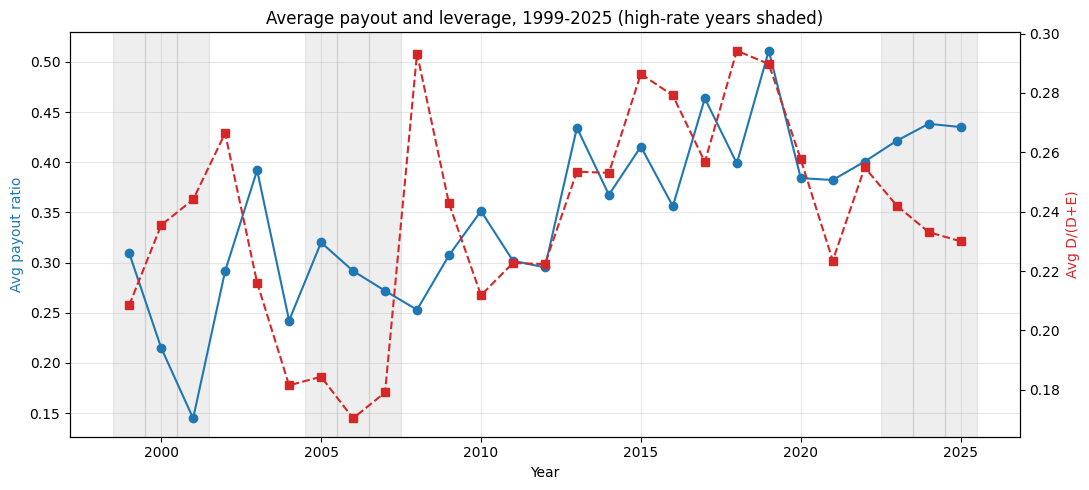

In [24]:
# Fig 2 — avg payout & leverage over time, high-rate years shaded
ts = panel.groupby("year")[["payout", "lev"]].mean()
hi_years = set(macro.loc[macro.high_rate == 1, "year"])
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(ts.index, ts["payout"], "o-", color="tab:blue", label="Avg payout")
ax1.set_ylabel("Avg payout ratio", color="tab:blue"); ax2 = ax1.twinx()
ax2.plot(ts.index, ts["lev"], "s--", color="tab:red", label="Avg leverage")
ax2.set_ylabel("Avg D/(D+E)", color="tab:red"); ax2.grid(False)
for y in hi_years:
    if y in ts.index: ax1.axvspan(y - .5, y + .5, color="gray", alpha=.13)
ax1.set_title("Average payout and leverage, 1999-2025 (high-rate years shaded)")
ax1.set_xlabel("Year"); fig.tight_layout()
fig.savefig(OUTDIR / "fig_payout_leverage_ts.png", dpi=150); plt.show()

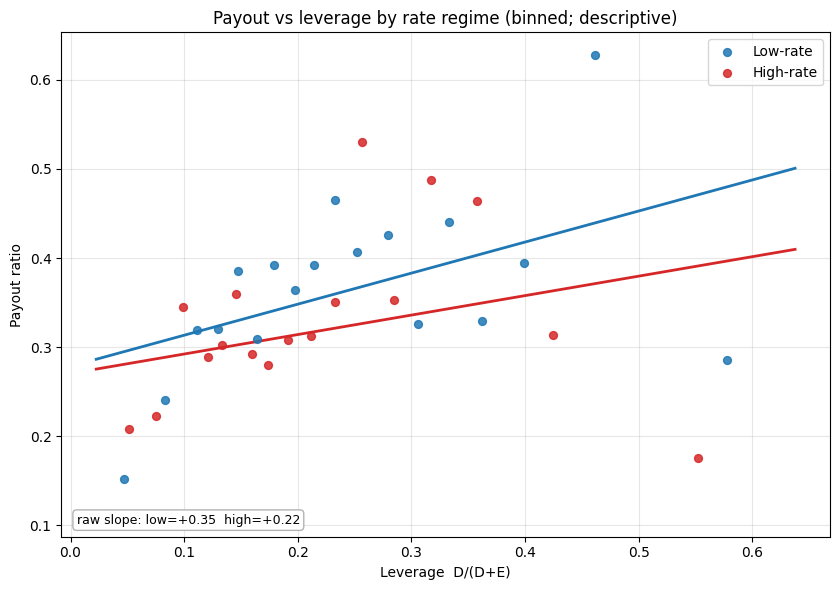

In [25]:
# Fig 3 — KEY H1/H2 visual: binned payout vs leverage by regime
def binscatter(ax, d, x, y, color, label, nbins=18):
    d = d[[x, y]].dropna(); q = min(nbins, d[x].nunique())
    d = d.assign(_b=pd.qcut(d[x], q, duplicates="drop"))
    g = d.groupby("_b").agg(xx=(x, "mean"), yy=(y, "mean"))
    ax.scatter(g["xx"], g["yy"], s=32, color=color, alpha=.85, label=label, zorder=3)
    b = np.polyfit(d[x], d[y], 1); xs = np.linspace(d[x].min(), d[x].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=color, lw=2)
    return b[0]
fig, ax = plt.subplots(figsize=(8.5, 6))
sl = binscatter(ax, panel[panel.high_rate == 0], "lev", "payout", "tab:blue", "Low-rate")
sh = binscatter(ax, panel[panel.high_rate == 1], "lev", "payout", "tab:red", "High-rate")
ax.set_xlabel("Leverage  D/(D+E)"); ax.set_ylabel("Payout ratio")
ax.set_title("Payout vs leverage by rate regime (binned; descriptive)")
ax.text(.02, .02, f"raw slope: low={sl:+.2f}  high={sh:+.2f}", transform=ax.transAxes,
        fontsize=9, va="bottom", bbox=dict(boxstyle="round", fc="white", ec="0.7"))
ax.legend(); fig.tight_layout()
fig.savefig(OUTDIR / "fig_payout_vs_leverage_by_regime.png", dpi=150); plt.show()

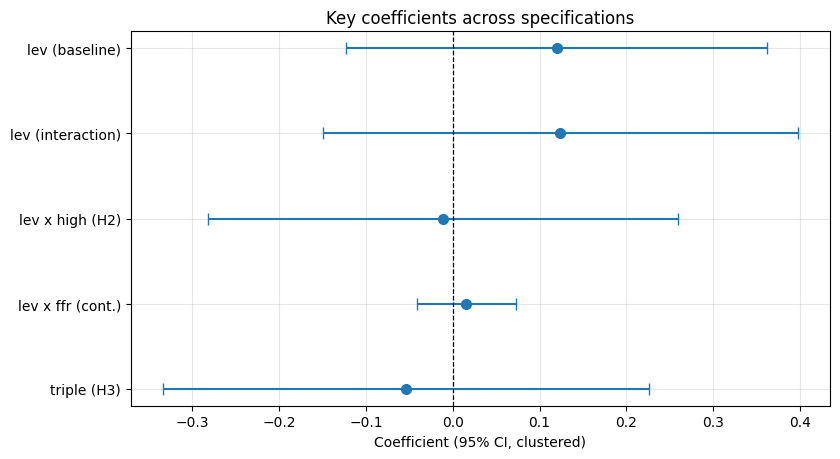

In [26]:
# Fig 4 — coefficient forest plot
def grab(res, key, label):
    if res is None or not hasattr(res, "params") or key not in res.params: return None
    b = res.params[key]; se = res.std_errors[key]; return (label, b, b - 1.96 * se, b + 1.96 * se)
specs = [grab(res_base, "lev", "lev (baseline)"), grab(res_int, "lev", "lev (interaction)"),
         grab(res_int, "lev_x_high", "lev x high (H2)"), grab(res_cont, "lev_x_ffr", "lev x ffr (cont.)"),
         grab(res_h3, "lev_x_high_x_tang", "triple (H3)") if "res_h3" in globals() else None]
specs = [s for s in specs if s]
fig, ax = plt.subplots(figsize=(8.5, .7 * len(specs) + 1.2))
for i, (lab, b, lo, hi) in enumerate(specs):
    ax.errorbar(b, i, xerr=[[b - lo], [hi - b]], fmt="o", color="tab:blue", capsize=4, markersize=7)
ax.axvline(0, color="k", lw=.9, ls="--"); ax.set_yticks(range(len(specs)))
ax.set_yticklabels([s[0] for s in specs]); ax.invert_yaxis()
ax.set_xlabel("Coefficient (95% CI, clustered)"); ax.set_title("Key coefficients across specifications")
fig.tight_layout(); fig.savefig(OUTDIR / "fig_coefficient_forest.png", dpi=150); plt.show()

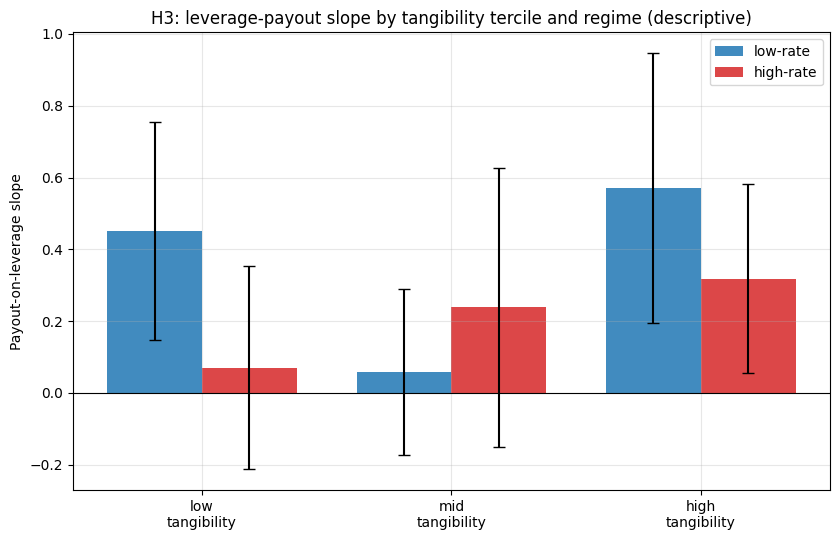

In [27]:
# Fig 5 — H3: payout~leverage slope by tangibility tercile x regime
import statsmodels.formula.api as smf
if panel["tangibility"].notna().any():
    panel["tang_grp"] = pd.qcut(panel["tangibility"], 3, labels=["low", "mid", "high"], duplicates="drop")
    cells = []
    for g in ["low", "mid", "high"]:
        for hr, lab in [(0, "low-rate"), (1, "high-rate")]:
            sub = panel[(panel.tang_grp == g) & (panel.high_rate == hr)][["payout", "lev"]].dropna()
            if len(sub) > 10:
                m = smf.ols("payout ~ lev", sub).fit(cov_type="HC1")
                cells.append((g, lab, m.params["lev"], m.bse["lev"]))
    cdf = pd.DataFrame(cells, columns=["tang", "regime", "slope", "se"])
    groups = ["low", "mid", "high"]; x = np.arange(len(groups)); w = .38
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    for k, (reg, col) in enumerate([("low-rate", "tab:blue"), ("high-rate", "tab:red")]):
        s = cdf[cdf.regime == reg].set_index("tang").reindex(groups)
        ax.bar(x + (k - .5) * w, s["slope"], w, yerr=1.96 * s["se"], capsize=4, color=col, label=reg, alpha=.85)
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels([f"{g}\ntangibility" for g in groups])
    ax.set_ylabel("Payout-on-leverage slope"); ax.legend()
    ax.set_title("H3: leverage-payout slope by tangibility tercile and regime (descriptive)")
    fig.tight_layout(); fig.savefig(OUTDIR / "fig_H3_slopes_by_tangibility.png", dpi=150); plt.show()

## 12 · Reproducibility & outputs  <span style="color:gray">(Appendices B & D)</span>

In [28]:
# Appendix B — industry persistence table
appendix_B = (persist.rename("years_present").reset_index()
              .assign(in_core=lambda d: d["industry"].isin(CORE)))
appendix_B.to_csv(OUTDIR / "appendix_B_industry_persistence.csv", index=False)
pd.Series(INDUSTRY_RENAME, name="canonical").rename_axis("original").to_csv(OUTDIR / "appendix_B_rename_map.csv")

panel.to_csv(OUTDIR / "analysis_panel.csv", index=False)
try: panel.to_parquet(OUTDIR / "analysis_panel.parquet", index=False)
except Exception: pass

print(f"Saved {len(list(OUTDIR.glob('*')))} files to {OUTDIR}/\n")
print(f"Panel: {panel['industry'].nunique()} industries x {panel['year'].nunique()} years "
      f"({panel.year.min()}-{panel.year.max()}) = {len(panel)} obs; core = {len(CORE)} industries\n")
for m in ["pandas", "numpy", "matplotlib", "statsmodels", "linearmodels", "xlrd"]:
    try: print(f"  {m:13s}", __import__(m).__version__)
    except Exception: print(f"  {m:13s} (missing)")
print("  python       ", sys.version.split()[0])

Saved 22 files to outputs/

Panel: 143 industries x 27 years (1999-2025) = 2116 obs; core = 46 industries

  pandas        3.0.2
  numpy         2.4.4
  matplotlib    3.10.9
  statsmodels   0.15.0
  linearmodels  7.0
  xlrd          2.0.2
  python        3.11.15


---
### Summary

- **Full 1999–2025 industry panel** built reproducibly from the Damodaran archives (era-proof loader) plus
  FRED macro data. Sample: US non-financial, non-utility industries.
- **Hypotheses tested directly:** H1/H2 via the `lev × HighRate` interaction (primary regime = rate-level
  threshold; post-2022 binary as robustness); H3 via the `lev × HighRate × tangibility` triple interaction.
- **Industry reconciliation** (Appendix B) handles Damodaran's 2012→2013 reclassification conservatively;
  a **stable-core sample** provides a robustness check immune to it.
- **Data-quality fixes:** depreciation-based tangibility excluded in 2013–2015 (capex depreciation break);
  H3 includes the tangibility main effect; macro controls enter only the industry-FE-only specification.
- **Power and bounds (§9b):** the H2 null is reported as a bound: the confidence interval rules out
  regime effects above a few payout points per SD of leverage, while smaller effects cannot be excluded.
- **Dividend smoothing (§8b):** dividends adjust slowly toward a target payout (Lintner), smoothing does not
  change across rate regimes, and H1 tested in change form (dividend changes) is not supported either.
- **Outputs** (`outputs/`): combined regression table (CSV + LaTeX), hypothesis verdicts, descriptive and
  proxy-robustness tables, the variable and industry appendices, and six publication-ready figures.
- **Caveats to read in the thesis:** tangibility is a Cap Ex/Depreciation proxy (cloud-capex caveat, §7.4);
  industry-level aggregation; the data is a repeated cross-section; results are associational.